In [1]:
%matplotlib inline

In [2]:

# ── Standard library ──────────────────────────────────────────────────────────
import os
import re
import json
import warnings
from pathlib import Path
from collections import Counter, defaultdict

warnings.filterwarnings("ignore")

# ── Third-party ───────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [3]:
# =============================================================================
#  CONFIGURATION — update DATA_DIR to point at your CSV folder
# =============================================================================

DATA_DIR   = Path(".")   
TRACKS = 'all'       # folder containing all five CSVs
OUTPUT_DIR = Path("outputs")    # all plots / models / results saved here
OUTPUT_DIR.mkdir(exist_ok=True)

REDDIT_FILES = {
    "FTX":     DATA_DIR / "reddit_sentiment_data_FTX_2024.csv",
    "Celsius": DATA_DIR / "reddit_sentiment_data_Celsius_2024.csv",
    "OneCoin": DATA_DIR / "reddit_sentiment_data_Onecoin_2024.csv",
    "Centra":  DATA_DIR / "reddit_sentiment_data_Centra_2024.csv",
}
BITCOINTALK_FILE = DATA_DIR / "bitcointalk_scam_data.csv"


In [4]:
# Known real-world event dates (used in Track 4 & 5)
COLLAPSE_DATES = {
    "FTX":     "2022-11-08",   # trading halt / SBF resignation
    "Celsius": "2022-06-12",   # withdrawal freeze
    "Centra":  "2018-04-01",   # SEC charges
    "OneCoin": "2019-03-06",   # Ruja Ignatova disappearance / DoJ indictment
}


# =============================================================================
#  SHARED UTILITIES
# =============================================================================


In [5]:
def clean_text(text: str) -> str:
    """Remove URLs, deleted placeholders, and extra whitespace."""
    if not isinstance(text, str):
        return ""
    text = re.sub(r"http\S+|www\.\S+", "", text)
    text = re.sub(r"\[deleted\]|\[removed\]", "", text, flags=re.IGNORECASE)
    text = re.sub(r"&amp;|&lt;|&gt;|&quot;|&#\d+;", " ", text)  # HTML entities
    text = re.sub(r"\s+", " ", text).strip()
    return text


In [6]:
def load_reddit(min_words: int = 5) -> pd.DataFrame:
    """Load and concatenate all four Reddit CSV files."""
    dfs = []
    for scam, path in REDDIT_FILES.items():
        df = pd.read_csv(path, dtype={"id": str, "parent_id": str})
        df["scam"] = scam
        dfs.append(df)
    df = pd.concat(dfs, ignore_index=True)
    df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"], errors="coerce")
    df["clean_text"]    = df["text"].apply(clean_text)
    df = df[df["clean_text"].str.split().str.len() >= min_words].reset_index(drop=True)
    return df


In [7]:
def load_bitcointalk(min_words: int = 5) -> pd.DataFrame:
    """Load Bitcointalk CSV."""
    df = pd.read_csv(BITCOINTALK_FILE, dtype={"id": str})
    df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"], errors="coerce")
    df["clean_text"]    = df["text"].apply(clean_text)
    df = df[df["clean_text"].str.split().str.len() >= min_words].reset_index(drop=True)
    df["scam"] = "Bitcointalk"
    return df

In [8]:
# def save_fig(fig, name: str):
#     """Save a matplotlib figure to OUTPUT_DIR."""
#     path = OUTPUT_DIR / f"{name}.png"
#     fig.savefig(path, dpi=150, bbox_inches="tight")
#     plt.close(fig)
#     print(f"  → saved {path}")
# NEW — displays inline in notebook
def save_fig(fig, name: str):
    plt.show()          # renders inline
    # plt.close(fig)

def save_plotly(fig, name: str):
    fig.show()          # renders inline

In [9]:
# def save_plotly(fig, name: str):
#     """Save a Plotly figure as interactive HTML."""
#     path = OUTPUT_DIR / f"{name}.html"
#     fig.write_html(str(path))
#     print(f"  → saved {path}")


# =============================================================================
#  TRACK 1 — TOPIC MODELLING & THEMATIC DISCOVERY
# =============================================================================


In [35]:
def track1_topic_modelling(df: pd.DataFrame):
    """
    1a. BERTopic — contextual neural topic model
    1b. LDA     — classical probabilistic topic model
    1c. NMF     — matrix factorisation topic model
    1d. Temporal topic drift per scam
    1e. Cross-scam topic comparison
    """
    print("\n" + "="*60)
    print("TRACK 1 — TOPIC MODELLING")
    print("="*60)

    # ── 1a. BERTopic ────────────────────────────────────────────────────────
    print("\n[1a] BERTopic …")
    # from bertopic import BERTopic
    # from sentence_transformers import SentenceTransformer
    # from umap import UMAP
    # from hdbscan import HDBSCAN
    # from sklearn.feature_extraction.text import CountVectorizer

    # docs       = df["clean_text"].tolist()
    # timestamps = df["timestamp_utc"].tolist()

    # embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

    # umap_model = UMAP(
    #     n_neighbors=15,
    #     n_components=5,
    #     min_dist=0.0,
    #     metric="cosine",
    #     random_state=42
    # )

    # hdbscan_model = HDBSCAN(
    #     min_cluster_size=80,
    #     min_samples=10,
    #     metric="euclidean",
    #     cluster_selection_method="eom",
    #     prediction_data=True
    # )

    # vectorizer = CountVectorizer(
    #     stop_words="english",
    #     ngram_range=(1, 2),
    #     min_df=10
    # )

    # topic_model = BERTopic(
    #     embedding_model=embedding_model,
    #     umap_model=umap_model,
    #     hdbscan_model=hdbscan_model,
    #     vectorizer_model=vectorizer,
    #     nr_topics="auto",
    #     top_n_words=10,
    #     calculate_probabilities=True,
    #     verbose=True
    # )

    # topics, probs = topic_model.fit_transform(docs)
    # df["bertopic_id"]   = topics
    # df["bertopic_prob"] = probs.max(axis=1)

    # # Save topic info
    # topic_info = topic_model.get_topic_info()
    # topic_info.to_csv(OUTPUT_DIR / "bertopic_topic_info.csv", index=False)
    # print(topic_info.head(20).to_string())

    # # Save model
    # topic_model.save(str(OUTPUT_DIR / "bertopic_model"), serialization="safetensors")

    # # Visualise topic space
    # fig_topics = topic_model.visualize_topics()
    # save_plotly(fig_topics, "bertopic_topic_space")

    # # Visualise top-topic keyword bars
    # fig_barchart = topic_model.visualize_barchart(top_n_topics=12)
    # save_plotly(fig_barchart, "bertopic_barchart")

    # # Heatmap — topic similarity
    # fig_heatmap = topic_model.visualize_heatmap()
    # save_plotly(fig_heatmap, "bertopic_heatmap")
   

    # # ── 1d. Temporal topic drift ─────────────────────────────────────────────
    # print("\n[1d] Temporal topic drift …")
    # topics_over_time = topic_model.topics_over_time(
    #     docs,
    #     timestamps,
    #     nr_bins=60,
    #     evolution_tuning=True,
    #     global_tuning=True
    # )
    # fig_tot = topic_model.visualize_topics_over_time(
    #     topics_over_time,
    #     top_n_topics=10
    # )
    # save_plotly(fig_tot, "bertopic_topics_over_time")
    # topics_over_time.to_csv(OUTPUT_DIR / "topics_over_time.csv", index=False)

    # # ── 1e. Per-scam BERTopic ────────────────────────────────────────────────
    # print("\n[1e] Per-scam BERTopic …")
    # scam_topic_dfs = {}
    # for scam in df["scam"].unique():
    #     subset = df[df["scam"] == scam]["clean_text"].tolist()
    #     if len(subset) < 200:
    #         print(f"  Skipping {scam} (too few docs: {len(subset)})")
    #         continue
    #     m = BERTopic(
    #         embedding_model=embedding_model,
    #         nr_topics=15,
    #         verbose=False
    #     )
    #     t, _ = m.fit_transform(subset)
    #     info = m.get_topic_info()
    #     info["scam"] = scam
    #     scam_topic_dfs[scam] = info
    #     info.to_csv(OUTPUT_DIR / f"bertopic_{scam}.csv", index=False)
    #     print(f"  {scam}: {len(info)} topics")
    df["bertopic_id"]   = -1
    df["bertopic_prob"] = 0.0
    topic_model = None
    
    # ── 1b. LDA ──────────────────────────────────────────────────────────────
    print("\n[1b] LDA (gensim) …")
    import gensim
    import gensim.corpora as corpora
    from gensim.utils import simple_preprocess
    from gensim.models import LdaMulticore
    from nltk.corpus import stopwords
    import nltk
    nltk.download("stopwords", quiet=True)

    stop_words = set(stopwords.words("english"))
    stop_words.update(["like", "just", "crypto", "cryptocurrency", "bitcoin"])

    def tokenise(text):
        return [w for w in simple_preprocess(text, deacc=True)
                if w not in stop_words and len(w) > 2]

    # Use a random sample for LDA — it doesn't need all 190k docs
    sample = df.sample(min(30_000, len(df)), random_state=42)
    tokenised = sample["clean_text"].apply(tokenise).tolist()

    id2word = corpora.Dictionary(tokenised)
    id2word.filter_extremes(no_below=20, no_above=0.5)
    corpus = [id2word.doc2bow(doc) for doc in tokenised]

    lda_model = LdaMulticore(
        corpus=corpus,
        id2word=id2word,
        num_topics=20,
        random_state=42,
        chunksize=1000,
        passes=5,
        workers=2,
        per_word_topics=True
    )

    # Print topics
    print("\nLDA Topics:")
    for idx, topic in lda_model.print_topics(num_topics=20, num_words=8):
        print(f"  Topic {idx:2d}: {topic}")

    # Save LDA visualisation
    try:
        import pyLDAvis
        import pyLDAvis.gensim_models
        from IPython.display import display, HTML
        vis = pyLDAvis.gensim_models.prepare(lda_model, corpus, id2word)
        pyLDAvis.enable_notebook()
        vis_html = pyLDAvis.prepared_data_to_html(vis)
        display(HTML(vis_html))
    #     import pyLDAvis
    #     import pyLDAvis.gensim_models
    #     vis = pyLDAvis.gensim_models.prepare(lda_model, corpus, id2word)
    #     # pyLDAvis.save_html(vis, str(OUTPUT_DIR / "lda_visualisation.html"))
    #     # print("  → saved lda_visualisation.html")
    #     pyLDAvis.enable_notebook()   # must call this once
    #     display(pyLDAvis.prepared_data_to_html(vis))  # renders inline
    except Exception as e:
        print(f"  pyLDAvis skipped: {e}")
         

    # Assign dominant LDA topic to each sample row
    lda_topics = []
    for bow in corpus:
        topic_probs = lda_model.get_document_topics(bow, minimum_probability=0.0)
        dominant    = max(topic_probs, key=lambda x: x[1])[0]
        lda_topics.append(dominant)
    sample["lda_topic"] = lda_topics
    sample[["id", "scam", "lda_topic"]].to_csv(OUTPUT_DIR / "lda_doc_topics.csv", index=False)

    # ── 1c. NMF ──────────────────────────────────────────────────────────────
    print("\n[1c] NMF (sklearn) …")
    from sklearn.decomposition import NMF
    from sklearn.feature_extraction.text import TfidfVectorizer

    tfidf = TfidfVectorizer(
        max_features=10_000,
        stop_words="english",
        ngram_range=(1, 2),
        min_df=10
    )
    tfidf_matrix = tfidf.fit_transform(sample["clean_text"])
    feature_names = tfidf.get_feature_names_out()

    nmf = NMF(n_components=20, random_state=42, max_iter=400)
    W   = nmf.fit_transform(tfidf_matrix)   # doc-topic matrix
    H   = nmf.components_                   # topic-word matrix

    print("\nNMF Topics:")
    for topic_idx, topic_vec in enumerate(H):
        top_words = [feature_names[i] for i in topic_vec.argsort()[:-11:-1]]
        print(f"  Topic {topic_idx:2d}: {', '.join(top_words)}")

    sample["nmf_topic"] = W.argmax(axis=1)
    sample[["id", "scam", "nmf_topic"]].to_csv(OUTPUT_DIR / "nmf_doc_topics.csv", index=False)

    return df, topic_model

In [36]:
if __name__ == "__main__":
    import argparse

    parser = argparse.ArgumentParser(description="Crypto Scam Full Analysis Pipeline")
    parser.add_argument(
        "--tracks", nargs="+",
        choices=["1", "2", "3", "4", "5", "6", "7", "8", "all"],
        default=["all"],
        help="Which analysis tracks to run (e.g. --tracks 1 3 5)"
    )
    parser.add_argument("--data-dir", type=str, default=".",
                        help="Directory containing the five CSV files")
    args, unknown = parser.parse_known_args()
    DATA_DIR = Path(args.data_dir)

    print("Loading data …")
    df_reddit = load_reddit(min_words=5)
    df_btc    = load_bitcointalk(min_words=5)
    print(f"Reddit: {len(df_reddit):,} rows | Bitcointalk: {len(df_btc):,} rows")

    run_all = "all" in args.tracks
    tracks  = args.tracks

    if run_all or "1" in tracks:
        df_reddit, topic_model = track1_topic_modelling(df_reddit)

    # if run_all or "2" in tracks:
    #     df_reddit = track2_emotion_stance(df_reddit)

    # if run_all or "3" in tracks:
    #     graphs = track3_network_analysis(df_reddit)

    # if run_all or "4" in tracks:
    #     df_features = track4_early_warning(df_reddit)

    # if run_all or "5" in tracks:
    #     fingerprints = track5_comparative(df_reddit, df_btc)

    # if run_all or "6" in tracks:
    #     ent_df = track6_knowledge_graph(df_reddit)

    # if run_all or "7" in tracks:
    #     track7_stylometrics(df_reddit)

    # if run_all or "8" in tracks:
    #     track8_enrichment(df_reddit)

    print("\n" + "="*60)
    print(f"ALL DONE — outputs saved to: {OUTPUT_DIR.resolve()}")
    print("="*60)


Loading data …
Reddit: 162,634 rows | Bitcointalk: 2,303 rows

TRACK 1 — TOPIC MODELLING

[1a] BERTopic …

[1b] LDA (gensim) …

LDA Topics:
  Topic  0: 0.025*"way" + 0.021*"nothing" + 0.020*"tip" + 0.015*"learn" + 0.014*"source" + 0.013*"tether" + 0.013*"someone" + 0.013*"system"
  Topic  1: 0.034*"wallet" + 0.030*"people" + 0.026*"exchanges" + 0.023*"exchange" + 0.018*"coins" + 0.014*"get" + 0.014*"use" + 0.013*"cold"
  Topic  2: 0.029*"year" + 0.018*"months" + 0.016*"usd" + 0.014*"run" + 0.014*"card" + 0.013*"million" + 0.012*"pay" + 0.012*"taxes"
  Topic  3: 0.050*"please" + 0.028*"subreddit" + 0.028*"message" + 0.028*"action" + 0.027*"contact" + 0.026*"questions" + 0.025*"bot" + 0.024*"automatically"
  Topic  4: 0.030*"people" + 0.022*"say" + 0.019*"shit" + 0.019*"would" + 0.016*"bad" + 0.015*"fuck" + 0.015*"know" + 0.012*"one"
  Topic  5: 0.045*"people" + 0.045*"money" + 0.024*"would" + 0.023*"make" + 0.015*"thanks" + 0.011*"sell" + 0.010*"care" + 0.010*"lot"
  Topic  6: 0.029*"mo


[1c] NMF (sklearn) …

NMF Topics:
  Topic  0: bitcoin, price, buy bitcoin, bitcoin bitcoin, cash, value, currency, bitcoin cash, good bitcoin, sell
  Topic  1: like, looks, looks like, sounds, sounds like, just like, feel, feel like, things, look
  Topic  2: automatically, subreddit, moderators, message, contact, bot, contact moderators, questions, action performed, performed automatically
  Topic  3: just, just like, man, got, say, want, just got, just don, just want, fuck
  Topic  4: money, make, lost, make money, lost money, bank, lose, lose money, people money, pay
  Topic  5: crypto, com, crypto com, fiat, banks, world, space, scam, exchanges, keys crypto
  Topic  6: don, know, don know, want, don think, don want, understand, need, don understand, trust
  Topic  7: celsius, got, funds, blockfi, shit, pay, voyager, nexo, network, assets
  Topic  8: people, lot, lot people, people don, rich, shit, people money, want, understand, people just
  Topic  9: lol, yeah, going, sub, man, d

# =============================================================================
#  TRACK 2 — FINE-GRAINED EMOTION & STANCE DETECTION
# =============================================================================


In [37]:
def track2_emotion_stance(df: pd.DataFrame):
    """
    2a. Multi-class emotion detection (GoEmotions / EmoRoBERTa)
    2b. Stance classification (believer / sceptic / victim / promoter)
    2c. Manipulation language detection (lexicon + ML)
    2d. Sarcasm detection
    """
    print("\n" + "="*60)
    print("TRACK 2 — EMOTION & STANCE DETECTION")
    print("="*60)

    from transformers import pipeline

    # Work on a manageable sample — transformer inference is slow on 190k docs
    # Scale up once validated
    sample = df.sample(min(20_000, len(df)), random_state=42).copy()
    texts  = sample["clean_text"].tolist()

    # ── 2a. Emotion Detection ────────────────────────────────────────────────
    print("\n[2a] Emotion detection (EmoRoBERTa) …")
    # 'SamLowe/roberta-base-go_emotions' — 28 emotion labels
    emotion_pipe = pipeline(
        "text-classification",
        model="SamLowe/roberta-base-go_emotions",
        top_k=3,
        truncation=True,
        max_length=512,
        device=-1          # set to 0 for GPU
    )

    BATCH = 64
    all_emotions = []
    for i in range(0, len(texts), BATCH):
        batch   = texts[i:i+BATCH]
        results = emotion_pipe(batch)
        for res in results:
            top_label = res[0]["label"]
            top_score = res[0]["score"]
            all_emotions.append({"emotion": top_label, "emotion_score": top_score})
        if i % 1000 == 0:
            print(f"  processed {i}/{len(texts)}")

    emotion_df = pd.DataFrame(all_emotions)
    sample["emotion"]       = emotion_df["emotion"].values
    sample["emotion_score"] = emotion_df["emotion_score"].values

    # Save
    sample[["id", "scam", "timestamp_utc", "emotion", "emotion_score"]].to_csv(
        OUTPUT_DIR / "emotion_labels.csv", index=False
    )

    # Plot emotion distribution per scam
    fig, axes = plt.subplots(1, len(df["scam"].unique()), figsize=(18, 5), sharey=True)
    for ax, scam in zip(axes, df["scam"].unique()):
        sub = sample[sample["scam"] == scam]
        counts = sub["emotion"].value_counts().head(10)
        ax.barh(counts.index, counts.values, color="steelblue")
        ax.set_title(scam, fontsize=11)
        ax.invert_yaxis()
    plt.suptitle("Top 10 Emotions per Scam", fontsize=13)
    plt.tight_layout()
    save_fig(fig, "emotion_distribution_per_scam")

    # Emotion over time (for FTX — most data)
    ftx = sample[sample["scam"] == "FTX"].copy()
    ftx["month"] = ftx["timestamp_utc"].dt.to_period("M").astype(str)
    pivot = ftx.groupby(["month", "emotion"]).size().unstack(fill_value=0)
    top_emotions = ftx["emotion"].value_counts().head(6).index
    fig2, ax2 = plt.subplots(figsize=(14, 5))
    for emo in top_emotions:
        if emo in pivot.columns:
            ax2.plot(pivot.index, pivot[emo], label=emo, marker="o", markersize=3)
    ax2.set_title("FTX — Top Emotions Over Time")
    ax2.set_xlabel("Month")
    ax2.tick_params(axis="x", rotation=45)
    ax2.legend()
    plt.tight_layout()
    save_fig(fig2, "ftx_emotion_over_time")

    # ── 2b. Stance Classification (Zero-shot) ────────────────────────────────
    print("\n[2b] Stance classification (zero-shot) …")
    # Uses MNLI model — no fine-tuning needed
    stance_pipe = pipeline(
        "zero-shot-classification",
        model="facebook/bart-large-mnli",
        device=-1
    )

    STANCE_LABELS = ["scam promotion", "scam warning", "victim complaint",
                     "neutral discussion", "sarcasm or mockery"]

    stance_sample = sample.sample(min(5000, len(sample)), random_state=1).copy()
    stance_texts  = stance_sample["clean_text"].tolist()

    stance_results = []
    for i in range(0, len(stance_texts), 32):
        batch = stance_texts[i:i+32]
        res   = stance_pipe(batch, candidate_labels=STANCE_LABELS, multi_label=False)
        for r in res:
            stance_results.append({
                "stance":       r["labels"][0],
                "stance_score": r["scores"][0]
            })
        if i % 500 == 0:
            print(f"  {i}/{len(stance_texts)}")

    stance_df = pd.DataFrame(stance_results)
    stance_sample["stance"]       = stance_df["stance"].values
    stance_sample["stance_score"] = stance_df["stance_score"].values
    stance_sample[["id", "scam", "timestamp_utc", "stance", "stance_score"]].to_csv(
        OUTPUT_DIR / "stance_labels.csv", index=False
    )

    # Stacked bar: stance breakdown per scam
    pivot_stance = stance_sample.groupby(["scam", "stance"]).size().unstack(fill_value=0)
    pivot_stance_pct = pivot_stance.div(pivot_stance.sum(axis=1), axis=0) * 100
    fig3, ax3 = plt.subplots(figsize=(10, 5))
    pivot_stance_pct.plot(kind="bar", stacked=True, ax=ax3, colormap="Set2")
    ax3.set_title("Stance Distribution per Scam (%)")
    ax3.set_xlabel("")
    ax3.tick_params(axis="x", rotation=30)
    ax3.legend(loc="upper right", fontsize=8)
    plt.tight_layout()
    save_fig(fig3, "stance_distribution_per_scam")

    # ── 2c. Manipulation Language Detection ─────────────────────────────────
    print("\n[2c] Manipulation language detection …")

    # Lexicon of manipulation patterns
    MANIPULATION_LEXICON = {
        "fomo_triggers":    [
            "don't miss", "last chance", "limited time", "act now", "once in a lifetime",
            "sell out", "hurry", "before it's too late", "exclusive", "only a few left"
        ],
        "authority_appeals": [
            "experts say", "ceo confirmed", "officially", "guaranteed", "100%",
            "proven", "endorsed by", "backed by", "certified", "as seen on"
        ],
        "urgency_framing":   [
            "right now", "today only", "this week only", "ends soon", "deadline",
            "immediate", "asap", "urgent", "time sensitive"
        ],
        "trust_exploitation": [
            "safe investment", "no risk", "can't lose", "money back", "insured",
            "regulated", "government approved", "bank-level security", "fdic", "protected"
        ],
        "social_proof":       [
            "everyone is", "millions of", "join thousands", "community of",
            "already have", "people are making", "viral", "trending"
        ],
    }

    def count_manipulation(text, lexicon):
        text_lower = text.lower()
        scores = {}
        for category, phrases in lexicon.items():
            count = sum(1 for p in phrases if p in text_lower)
            scores[category] = count
        scores["total_manipulation"] = sum(scores.values())
        return scores

    manip_records = sample["clean_text"].apply(
        lambda t: count_manipulation(t, MANIPULATION_LEXICON)
    )
    manip_df = pd.DataFrame(manip_records.tolist())
    sample = pd.concat([sample.reset_index(drop=True), manip_df], axis=1)

    # Manipulation score by scam
    manip_by_scam = sample.groupby("scam")["total_manipulation"].mean().sort_values(ascending=False)
    fig4, ax4 = plt.subplots(figsize=(8, 4))
    manip_by_scam.plot(kind="bar", color="coral", ax=ax4)
    ax4.set_title("Average Manipulation Score per Scam")
    ax4.set_xlabel("")
    ax4.tick_params(axis="x", rotation=30)
    plt.tight_layout()
    save_fig(fig4, "manipulation_score_per_scam")

    # Top manipulation phrases
    all_tokens = []
    for text in sample[sample["total_manipulation"] > 0]["clean_text"]:
        for phrases in MANIPULATION_LEXICON.values():
            for p in phrases:
                if p in text.lower():
                    all_tokens.append(p)
    phrase_counts = Counter(all_tokens).most_common(20)
    fig5, ax5 = plt.subplots(figsize=(10, 5))
    labels, counts = zip(*phrase_counts) if phrase_counts else ([], [])
    ax5.barh(list(labels), list(counts), color="tomato")
    ax5.set_title("Most Frequent Manipulation Phrases")
    ax5.invert_yaxis()
    plt.tight_layout()
    save_fig(fig5, "manipulation_phrases")

    sample[["id", "scam"] + list(MANIPULATION_LEXICON.keys()) + ["total_manipulation"]].to_csv(
        OUTPUT_DIR / "manipulation_scores.csv", index=False
    )

    # ── 2d. Sarcasm Detection ────────────────────────────────────────────────
    print("\n[2d] Sarcasm detection …")
    # Using a dedicated sarcasm model fine-tuned on Reddit
    sarcasm_pipe = pipeline(
        "text-classification",
        model="helinivan/english-sarcasm-detector",
        truncation=True,
        max_length=512,
        device=-1
    )

    sarcasm_sample = sample.sample(min(5000, len(sample)), random_state=2).copy()
    sarcasm_texts  = sarcasm_sample["clean_text"].tolist()

    sarcasm_results = []
    for i in range(0, len(sarcasm_texts), BATCH):
        batch = sarcasm_texts[i:i+BATCH]
        res   = sarcasm_pipe(batch)
        for r in res:
            sarcasm_results.append({
                "sarcasm_label": r["label"],
                "sarcasm_score": r["score"]
            })

    sarc_df = pd.DataFrame(sarcasm_results)
    sarcasm_sample["sarcasm_label"] = sarc_df["sarcasm_label"].values
    sarcasm_sample["sarcasm_score"] = sarc_df["sarcasm_score"].values
    sarcasm_sample[["id", "scam", "clean_text", "sarcasm_label", "sarcasm_score"]].to_csv(
        OUTPUT_DIR / "sarcasm_labels.csv", index=False
    )

    # Sarcasm rate per scam
    sar_rate = (
        sarcasm_sample[sarcasm_sample["sarcasm_label"] == "SARCASM"]
        .groupby("scam").size()
        / sarcasm_sample.groupby("scam").size()
    ).fillna(0) * 100
    print("Sarcasm rate (%) per scam:\n", sar_rate)

    return sample


Loading data …
Reddit: 162,634 rows | Bitcointalk: 2,303 rows

TRACK 2 — EMOTION & STANCE DETECTION

[2a] Emotion detection (EmoRoBERTa) …


Device set to use cpu


  processed 0/20000
  processed 8000/20000
  processed 16000/20000


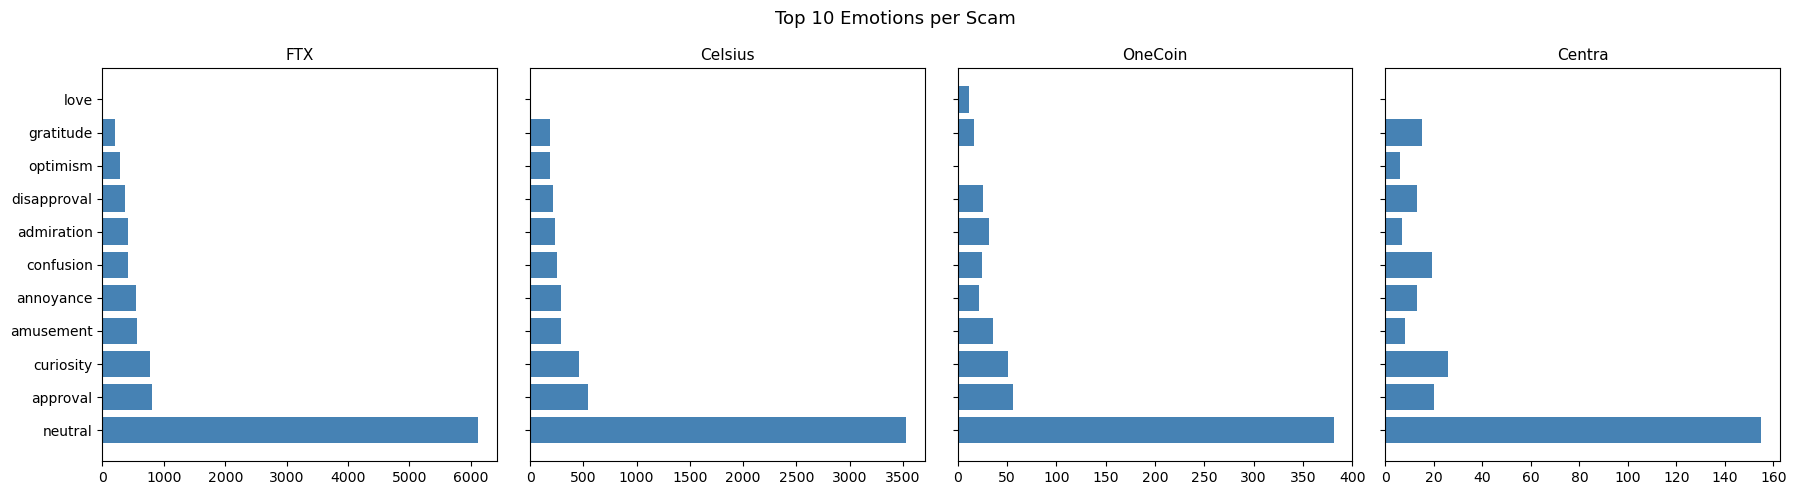

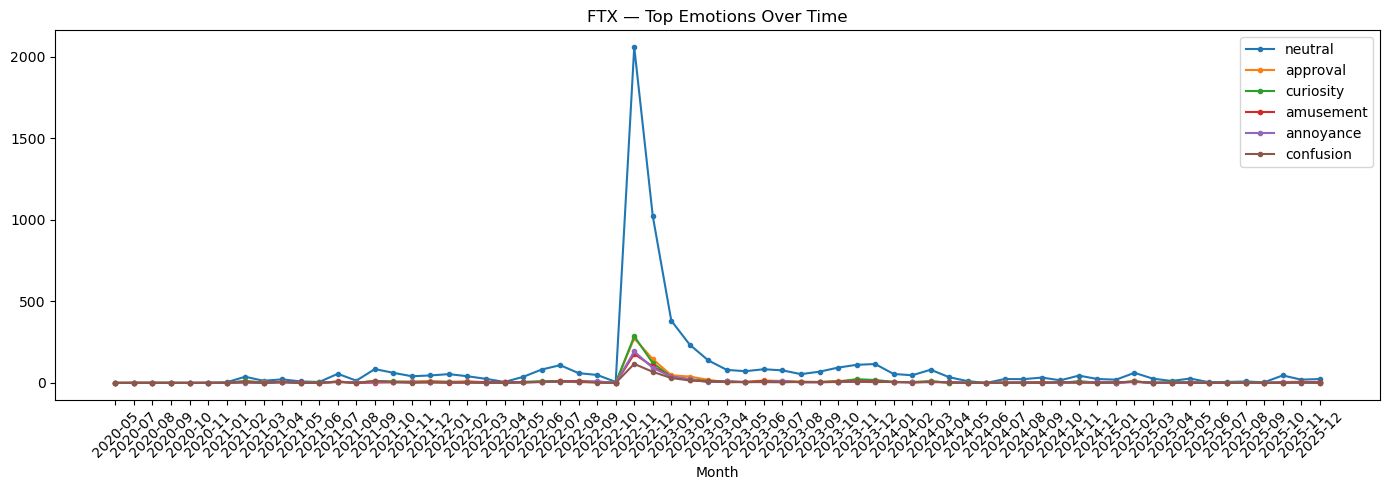


[2b] Stance classification (zero-shot) …


Device set to use cpu


  0/5000
  4000/5000


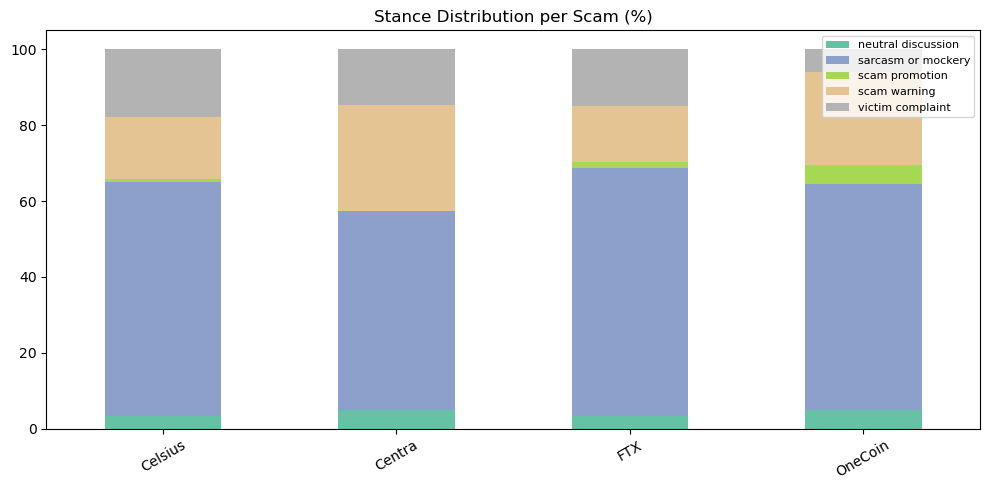


[2c] Manipulation language detection …


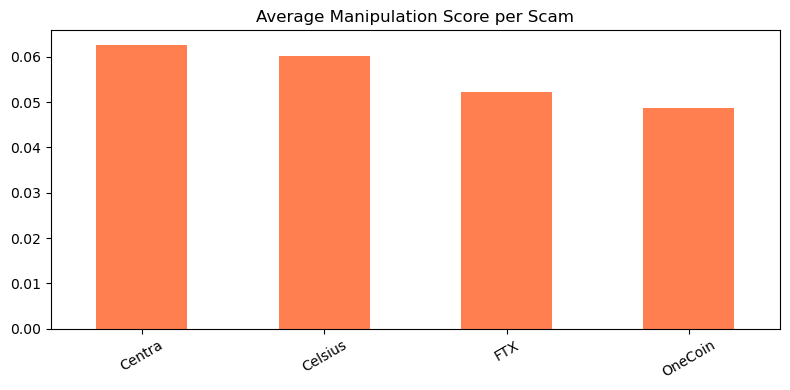

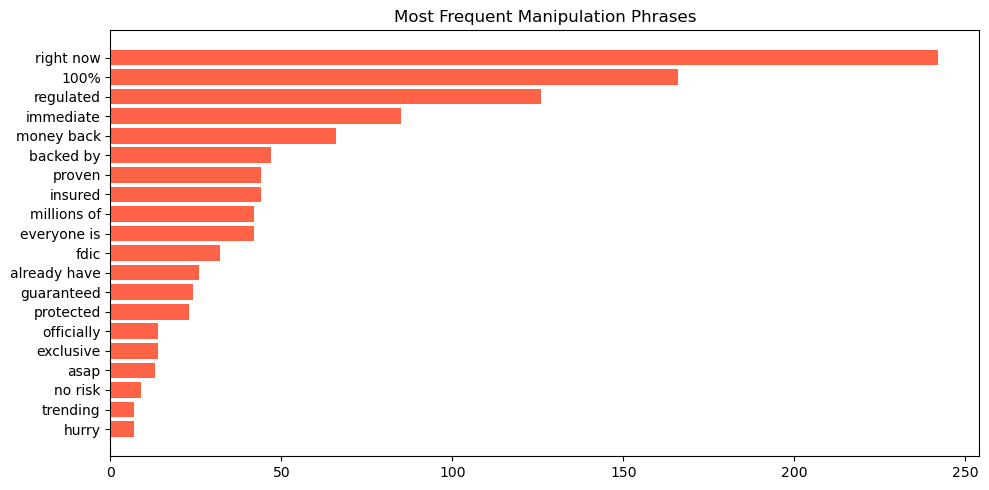


[2d] Sarcasm detection …


ValueError: Could not load model helinivan/english-sarcasm-detector with any of the following classes: (<class 'transformers.models.auto.modeling_auto.AutoModelForSequenceClassification'>, <class 'transformers.models.bert.modeling_bert.BertForSequenceClassification'>). See the original errors:

while loading with AutoModelForSequenceClassification, an error is thrown:
Traceback (most recent call last):
  File "c:\Users\User\anaconda3\lib\site-packages\transformers\pipelines\base.py", line 293, in infer_framework_load_model
    model = model_class.from_pretrained(model, **kwargs)
  File "c:\Users\User\anaconda3\lib\site-packages\transformers\models\auto\auto_factory.py", line 604, in from_pretrained
    return model_class.from_pretrained(
  File "c:\Users\User\anaconda3\lib\site-packages\transformers\modeling_utils.py", line 277, in _wrapper
    return func(*args, **kwargs)
  File "c:\Users\User\anaconda3\lib\site-packages\transformers\modeling_utils.py", line 5048, in from_pretrained
 

In [38]:
if __name__ == "__main__":
    import argparse

    parser = argparse.ArgumentParser(description="Crypto Scam Full Analysis Pipeline")
    parser.add_argument(
        "--tracks", nargs="+",
        choices=["1", "2", "3", "4", "5", "6", "7", "8", "all"],
        default=["all"],
        help="Which analysis tracks to run (e.g. --tracks 1 3 5)"
    )
    parser.add_argument("--data-dir", type=str, default=".",
                        help="Directory containing the five CSV files")
    args, unknown = parser.parse_known_args()
    DATA_DIR = Path(args.data_dir)

    print("Loading data …")
    df_reddit = load_reddit(min_words=5)
    df_btc    = load_bitcointalk(min_words=5)
    print(f"Reddit: {len(df_reddit):,} rows | Bitcointalk: {len(df_btc):,} rows")

    run_all = "all" in args.tracks
    tracks  = args.tracks

    # if run_all or "1" in tracks:
    #     df_reddit, topic_model = track1_topic_modelling(df_reddit)

    if run_all or "2" in tracks:
        df_reddit = track2_emotion_stance(df_reddit)

    # if run_all or "3" in tracks:
    #     graphs = track3_network_analysis(df_reddit)

    # if run_all or "4" in tracks:
    #     df_features = track4_early_warning(df_reddit)

    # if run_all or "5" in tracks:
    #     fingerprints = track5_comparative(df_reddit, df_btc)

    # if run_all or "6" in tracks:
    #     ent_df = track6_knowledge_graph(df_reddit)

    # if run_all or "7" in tracks:
    #     track7_stylometrics(df_reddit)

    # if run_all or "8" in tracks:
    #     track8_enrichment(df_reddit)

    print("\n" + "="*60)
    print(f"ALL DONE — outputs saved to: {OUTPUT_DIR.resolve()}")
    print("="*60)


# =============================================================================
#  TRACK 3 — SOCIAL NETWORK & USER BEHAVIOUR ANALYSIS
# =============================================================================


In [41]:
def track3_network_analysis(df: pd.DataFrame):
    """
    3a. Reply network graph per scam (from parent_id)
    3b. Community detection
    3c. Astroturfing / bot detection
    3d. Information cascade analysis
    3e. User longitudinal behaviour
    """
    print("\n" + "="*60)
    print("TRACK 3 — SOCIAL NETWORK ANALYSIS")
    print("="*60)

    import networkx as nx
    try:
        import community as community_louvain     # python-louvain
    except ImportError:
        print("  pip install python-louvain for community detection")
        community_louvain = None

    try:
        from pyvis.network import Network as PyvisNetwork
        PYVIS = True
    except ImportError:
        PYVIS = False

    reddit = df[df["scam"] != "Bitcointalk"].copy()
    reddit["parent_id_clean"] = reddit["parent_id"].str.replace(r"^t\d_", "", regex=True)

    # ── 3a. Build Reply Graph ────────────────────────────────────────────────
    print("\n[3a] Building reply network graphs …")
    scam_graphs = {}

    for scam in reddit["scam"].unique():
        sub    = reddit[reddit["scam"] == scam].copy()
        G      = nx.DiGraph()
        author_map = sub.set_index("id")["author"].to_dict()

        edges_added = 0
        for _, row in sub.iterrows():
            if pd.notna(row["parent_id_clean"]) and row["parent_id_clean"] in author_map:
                src = author_map[row["parent_id_clean"]]
                dst = row["author"]
                if src and dst and src != "[deleted]" and dst != "[deleted]":
                    if G.has_edge(src, dst):
                        G[src][dst]["weight"] += 1
                    else:
                        G.add_edge(src, dst, weight=1)
                        edges_added += 1

        scam_graphs[scam] = G
        print(f"  {scam}: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

        # Network metrics
        if G.number_of_nodes() > 0:
            in_degree  = dict(G.in_degree(weight="weight"))
            out_degree = dict(G.out_degree(weight="weight"))
            top_in  = sorted(in_degree.items(),  key=lambda x: x[1], reverse=True)[:10]
            top_out = sorted(out_degree.items(), key=lambda x: x[1], reverse=True)[:10]
            print(f"    Top influencers (in-degree):  {top_in}")
            print(f"    Top broadcasters (out-degree): {top_out}")

            # Save as CSV edge list
            nx.write_edgelist(G, str(OUTPUT_DIR / f"graph_{scam}.edgelist"))

        # Pyvis interactive graph (top 200 nodes by degree)
        if PYVIS and G.number_of_nodes() > 0:
            top_nodes = sorted(G.degree(), key=lambda x: x[1], reverse=True)[:200]
            subG = G.subgraph([n for n, _ in top_nodes])
            import tempfile, os
            from IPython.display import display, HTML
            net = PyvisNetwork(height="600px", width="100%", directed=True, notebook=True)
            net.from_nx(subG)
            tmp_path = os.path.join(tempfile.gettempdir(), f"network_{scam}.html")
            net.save_graph(tmp_path)
            display(HTML(open(tmp_path, encoding="utf-8").read()))
    # ── 3b. Community Detection ──────────────────────────────────────────────
    print("\n[3b] Community detection (Louvain) …")
    if community_louvain:
        for scam, G in scam_graphs.items():
            if G.number_of_nodes() < 10:
                continue
            G_undirected = G.to_undirected()
            partition    = community_louvain.best_partition(G_undirected)
            n_communities = len(set(partition.values()))
            print(f"  {scam}: {n_communities} communities")

            community_df = pd.DataFrame(
                list(partition.items()), columns=["author", "community"]
            )
            # Merge with scam-specific posts
            merged = reddit[reddit["scam"] == scam].merge(community_df, on="author", how="left")
            # Describe each community by its dominant topics / keywords
            for cid in community_df["community"].value_counts().head(5).index:
                members = community_df[community_df["community"] == cid]["author"].tolist()
                texts_  = reddit[reddit["author"].isin(members)]["clean_text"].str.cat(sep=" ")
                # Top words
                words = re.findall(r"\b[a-zA-Z]{4,}\b", texts_.lower())
                common = Counter(words).most_common(8)
                print(f"    Community {cid} ({len(members)} users): {common}")

            community_df.to_csv(OUTPUT_DIR / f"communities_{scam}.csv", index=False)

    # ── 3c. Bot / Astroturfing Detection ─────────────────────────────────────
    print("\n[3c] Bot/astroturfing detection …")

    # Heuristics:
    #   - High posting frequency (>20 posts/day)
    #   - Short inter-post intervals
    #   - Unusually high lexical repetition
    #   - Posting at odd hours consistently

    user_stats = reddit.groupby("author").agg(
        post_count     = ("id", "count"),
        first_post     = ("timestamp_utc", "min"),
        last_post      = ("timestamp_utc", "max"),
        avg_text_len   = ("clean_text", lambda x: x.str.len().mean()),
        unique_words   = ("clean_text", lambda x: len(set(" ".join(x).lower().split()))),
    ).reset_index()

    user_stats["active_days"] = (
        (user_stats["last_post"] - user_stats["first_post"]).dt.total_seconds() / 86400
    ).clip(lower=1)
    user_stats["posts_per_day"] = user_stats["post_count"] / user_stats["active_days"]

    # Hour-of-day entropy per user (low entropy = always posts at same hour)
    hour_entropy = {}
    for author, grp in reddit.groupby("author"):
        if len(grp) < 5:
            continue
        hours = grp["timestamp_utc"].dt.hour.value_counts(normalize=True)
        entropy = -sum(p * np.log2(p + 1e-9) for p in hours)
        hour_entropy[author] = entropy
    user_stats["hour_entropy"] = user_stats["author"].map(hour_entropy)

    # Text similarity (repetition score) — authors posting near-identical content
    def repetition_score(texts):
        if len(texts) < 3:
            return 0.0
        texts_ = [t[:100] for t in texts]  # compare first 100 chars
        unique_ = len(set(texts_))
        return 1 - (unique_ / len(texts_))

    rep_scores = {}
    for author, grp in reddit.groupby("author"):
        if len(grp) >= 3:
            rep_scores[author] = repetition_score(grp["clean_text"].tolist())
    user_stats["repetition_score"] = user_stats["author"].map(rep_scores).fillna(0)

    # Bot score composite (z-score approach)
    from scipy.stats import zscore
    for col in ["posts_per_day", "repetition_score"]:
        user_stats[f"{col}_z"] = zscore(user_stats[col].fillna(0))
    user_stats["bot_score"] = (
        user_stats["posts_per_day_z"] * 0.4 +
        user_stats["repetition_score_z"] * 0.4 +
        (4.0 - user_stats["hour_entropy"].fillna(4.0)) * 0.2
    )

    suspicious = user_stats[user_stats["bot_score"] > 2.0].sort_values(
        "bot_score", ascending=False
    )
    print(f"  Suspicious accounts detected: {len(suspicious)}")
    print(suspicious[["author", "post_count", "posts_per_day",
                       "repetition_score", "bot_score"]].head(20).to_string())
    user_stats.to_csv(OUTPUT_DIR / "user_stats_bot_scores.csv", index=False)

    # ── 3d. Information Cascade Analysis ─────────────────────────────────────
    print("\n[3d] Information cascade analysis …")

    # For each root post, measure reply tree depth and breadth
    def cascade_metrics(sub_df):
        # Build parent→children map
        id_to_parent = sub_df.set_index("id")["parent_id_clean"].to_dict()
        children_map = defaultdict(list)
        for doc_id, parent in id_to_parent.items():
            if pd.notna(parent):
                children_map[parent].append(doc_id)

        root_posts = sub_df[sub_df["type"] == "post"]["id"].tolist()
        cascade_records = []
        for root in root_posts:
            # BFS
            queue, depth, visited = [root], 0, {root}
            max_depth, total_replies = 0, 0
            while queue:
                next_q = []
                for node in queue:
                    for child in children_map.get(node, []):
                        if child not in visited:
                            visited.add(child)
                            next_q.append(child)
                            total_replies += 1
                if next_q:
                    depth += 1
                    max_depth = depth
                queue = next_q
            cascade_records.append({
                "root_id":      root,
                "max_depth":    max_depth,
                "total_replies": total_replies,
            })
        return pd.DataFrame(cascade_records)

    cascade_dfs = []
    for scam in reddit["scam"].unique():
        sub   = reddit[reddit["scam"] == scam].copy()
        casc  = cascade_metrics(sub)
        casc["scam"] = scam
        cascade_dfs.append(casc)
    cascade_all = pd.concat(cascade_dfs, ignore_index=True)
    cascade_all.to_csv(OUTPUT_DIR / "cascade_metrics.csv", index=False)

    # Plot cascade depth distribution per scam
    fig, ax = plt.subplots(figsize=(10, 5))
    for scam in cascade_all["scam"].unique():
        sub = cascade_all[cascade_all["scam"] == scam]["max_depth"]
        ax.hist(sub, bins=30, alpha=0.5, label=scam, density=True)
    ax.set_title("Reply Thread Depth Distribution per Scam")
    ax.set_xlabel("Max depth")
    ax.legend()
    plt.show()

    # ── 3e. User Longitudinal Behaviour ──────────────────────────────────────
    print("\n[3e] User longitudinal behaviour …")

    # FTX: compare posting volume 90 days before vs after collapse
    ftx = reddit[reddit["scam"] == "FTX"].copy()
    collapse = pd.Timestamp(COLLAPSE_DATES["FTX"])

    ftx["days_from_collapse"] = (ftx["timestamp_utc"] - collapse).dt.days
    window = ftx[ftx["days_from_collapse"].between(-90, 90)]

    daily_vol = window.groupby("days_from_collapse").size().reset_index(name="posts")
    fig2, ax2 = plt.subplots(figsize=(14, 4))
    ax2.plot(daily_vol["days_from_collapse"], daily_vol["posts"], lw=1.5, color="steelblue")
    ax2.axvline(0, color="red", linestyle="--", label="FTX collapse (Nov 8 2022)")
    ax2.fill_between(daily_vol["days_from_collapse"], daily_vol["posts"], alpha=0.2)
    ax2.set_title("FTX Reddit posting volume: 90 days before/after collapse")
    ax2.set_xlabel("Days from collapse")
    ax2.set_ylabel("Posts per day")
    ax2.legend()
    plt.show()

    # New vs returning users around collapse
    pre_authors  = set(ftx[ftx["days_from_collapse"].between(-90, 0)]["author"])
    post_authors = set(ftx[ftx["days_from_collapse"].between(0, 90)]["author"])
    new_users    = post_authors - pre_authors
    print(f"  FTX: {len(new_users)} new authors appeared after collapse "
          f"({len(new_users)/len(post_authors)*100:.1f}% of post-collapse authors)")

    return scam_graphs


Loading data …
Reddit: 162,634 rows | Bitcointalk: 2,303 rows

TRACK 3 — SOCIAL NETWORK ANALYSIS

[3a] Building reply network graphs …
  FTX: 29457 nodes, 67534 edges
    Top influencers (in-degree):  [('AutoModerator', 649), ('MrPuma86', 301), ('kirtash93', 300), ('partymsl', 296), ('EthTraderCommunity', 283), ('Odysseus_Lannister', 243), ('deathbyfish13', 225), ('user260421', 221), ('Hawke64', 211), ('Lillica_Golden_SHIB', 202)]
    Top broadcasters (out-degree): [('partymsl', 1869), ('Beyonderr', 1516), ('OneThatNoseOne', 969), ('Set1Less', 733), ('kirtash93', 651), ('Odysseus_Lannister', 638), ('ChemicalGreek', 579), ('RealVoldemort', 483), ('Chysce', 432), ('SwimOld5053', 392)]


  Celsius: 19759 nodes, 40282 edges
    Top influencers (in-degree):  [('AutoModerator', 249), ('MrPuma86', 194), ('kirtash93', 157), ('partymsl', 148), ('EthTraderCommunity', 115), ('coinfeeds-bot', 113), ('user260421', 112), ('Megalorye', 95), ('deathbyfish13', 93), ('SwimOld5053', 91)]
    Top broadcasters (out-degree): [('partymsl', 865), ('Set1Less', 681), ('GabeSter', 468), ('Beyonderr', 447), ('SwimOld5053', 392), ('TarkovReddit0r', 316), ('CalculatedLuck', 267), ('OneThatNoseOne', 245), ('bad-crypto-advice', 233), ('ILostHalfaBTC', 232)]


  OneCoin: 3027 nodes, 4229 edges
    Top influencers (in-degree):  [('AutoModerator', 38), ('ethereumflow', 38), ('dan_from_san_diego', 32), ('BradVet', 28), ('coinfeeds-bot', 23), ('SON_OF_ANARCHY_', 22), ('MrPuma86', 22), ('kirtash93', 20), ('MrBitcoinNorway', 16), ('user260421', 15)]
    Top broadcasters (out-degree): [('Sethdarkus', 195), ('PM_Poutine', 185), ('tfren99', 149), ('dypeverdier', 140), ('pseudoHappyHippy', 97), ('BLordsc2', 73), ('soytendies', 67), ('kirtash93', 64), ('InevitableSoundOf', 63), ('ethereumflow', 61)]


  Centra: 1241 nodes, 1547 edges
    Top influencers (in-degree):  [('galan77', 33), ('AutoModerator', 20), ('teeceaustralia', 19), ('CapablePiglet1044', 10), ('wealthsuccessful007', 9), ('JuicySpark', 8), ('meatforsale', 8), ('Kuna_shiri', 8), ('sbellos74', 7), ('Salt-Device-6172', 7)]
    Top broadcasters (out-degree): [('JuicySpark', 123), ('OneThatNoseOne', 114), ('teeceaustralia', 95), ('galan77', 81), ('Weary_Strawberry2679', 49), ('Salt-Device-6172', 49), ('Marquszar', 30), ('achaldu', 30), ('CriticalCobraz', 29), ('WineMakerBg', 26)]



[3b] Community detection (Louvain) …
  FTX: 240 communities
    Community 7 (3568 users): [('that', 6917), ('they', 4430), ('bitcoin', 3828), ('this', 3687), ('have', 3252), ('your', 3051), ('with', 2873), ('people', 2212)]
    Community 0 (2967 users): [('that', 4765), ('this', 3459), ('they', 3073), ('have', 1925), ('with', 1904), ('just', 1843), ('crypto', 1760), ('people', 1605)]
    Community 1 (2695 users): [('that', 6461), ('this', 4568), ('they', 4055), ('with', 2774), ('just', 2577), ('have', 2532), ('crypto', 2481), ('people', 2311)]
    Community 18 (1994 users): [('this', 6828), ('that', 4428), ('have', 3501), ('your', 3366), ('they', 2883), ('with', 2451), ('will', 2142), ('please', 1905)]
    Community 22 (1704 users): [('that', 2658), ('this', 1675), ('solana', 1637), ('they', 1363), ('with', 1273), ('have', 1250), ('will', 1011), ('your', 1000)]
  Celsius: 187 communities
    Community 4 (2750 users): [('that', 7986), ('this', 5544), ('they', 4790), ('have', 3207), ('w

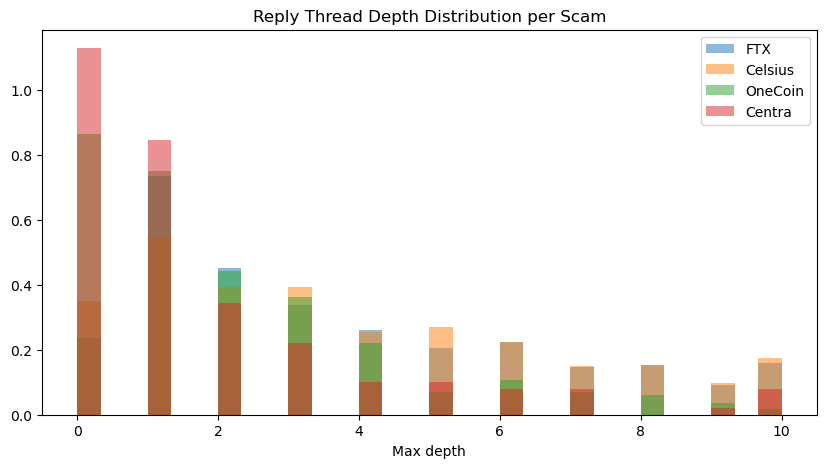


[3e] User longitudinal behaviour …


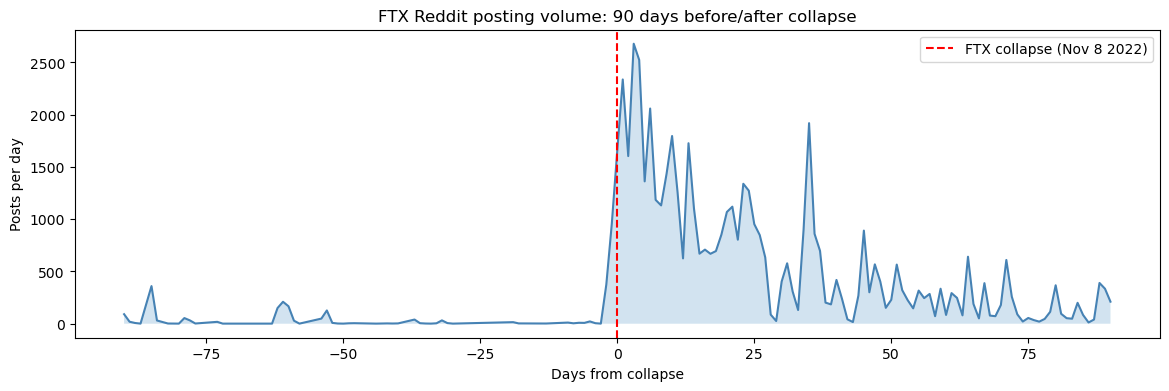

  FTX: 16228 new authors appeared after collapse (91.1% of post-collapse authors)

ALL DONE — outputs saved to: C:\Users\User\Desktop\New folder\Reddit Data\outputs


In [42]:
if __name__ == "__main__":
    import argparse

    parser = argparse.ArgumentParser(description="Crypto Scam Full Analysis Pipeline")
    parser.add_argument(
        "--tracks", nargs="+",
        choices=["1", "2", "3", "4", "5", "6", "7", "8", "all"],
        default=["all"],
        help="Which analysis tracks to run (e.g. --tracks 1 3 5)"
    )
    parser.add_argument("--data-dir", type=str, default=".",
                        help="Directory containing the five CSV files")
    args, unknown = parser.parse_known_args()
    DATA_DIR = Path(args.data_dir)

    print("Loading data …")
    df_reddit = load_reddit(min_words=5)
    df_btc    = load_bitcointalk(min_words=5)
    print(f"Reddit: {len(df_reddit):,} rows | Bitcointalk: {len(df_btc):,} rows")

    run_all = "all" in args.tracks
    tracks  = args.tracks

    # if run_all or "1" in tracks:
    #     df_reddit, topic_model = track1_topic_modelling(df_reddit)

    # if run_all or "2" in tracks:
    #     df_reddit = track2_emotion_stance(df_reddit)

    if run_all or "3" in tracks:
        graphs = track3_network_analysis(df_reddit)

    # if run_all or "4" in tracks:
    #     df_features = track4_early_warning(df_reddit)

    # if run_all or "5" in tracks:
    #     fingerprints = track5_comparative(df_reddit, df_btc)

    # if run_all or "6" in tracks:
    #     ent_df = track6_knowledge_graph(df_reddit)

    # if run_all or "7" in tracks:
    #     track7_stylometrics(df_reddit)

    # if run_all or "8" in tracks:
    #     track8_enrichment(df_reddit)

    print("\n" + "="*60)
    print(f"ALL DONE — outputs saved to: {OUTPUT_DIR.resolve()}")
    print("="*60)


# =============================================================================
#  TRACK 4 — EARLY WARNING SYSTEM & PREDICTIVE MODELLING
# =============================================================================


In [43]:
def track4_early_warning(df: pd.DataFrame):
    """
    4a. Pre-collapse signal extraction & feature engineering
    4b. Multi-class fraud taxonomy classifier
    4c. Survival analysis (time-to-collapse from first warning)
    4d. Risk scoring pipeline
    """
    print("\n" + "="*60)
    print("TRACK 4 — EARLY WARNING SYSTEM")
    print("="*60)

    from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
    from sklearn.linear_model import LogisticRegression
    from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
    from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
    from sklearn.preprocessing import LabelEncoder, StandardScaler
    from sklearn.feature_extraction.text import TfidfVectorizer
    from scipy.stats import zscore

    # ── 4a. Pre-collapse Feature Engineering ─────────────────────────────────
    print("\n[4a] Pre-collapse signal extraction …")

    # Keywords associated with warning signals (expand these)
    WARNING_KEYWORDS = [
        "withdraw", "withdrawal", "can't withdraw", "frozen", "suspended",
        "bankrupt", "insolvent", "rug pull", "exit scam", "fraud", "scam",
        "ponzi", "run away", "disappeared", "missing funds", "no response",
        "beware", "warning", "avoid", "stay away", "red flag", "too good",
        "lost money", "lost everything", "loss", "unable to access"
    ]

    PROMOTION_KEYWORDS = [
        "moon", "lambo", "hodl", "buy the dip", "all in", "100x", "guaranteed",
        "passive income", "life changing", "get rich", "no risk", "safe",
        "best investment", "recommended", "join now", "don't miss"
    ]

    def keyword_ratio(text, keywords):
        text_lower = text.lower()
        hits = sum(1 for k in keywords if k in text_lower)
        return hits

    reddit = df[df["scam"] != "Bitcointalk"].copy()
    reddit["warning_score"]   = reddit["clean_text"].apply(
        lambda t: keyword_ratio(t, WARNING_KEYWORDS))
    reddit["promotion_score"] = reddit["clean_text"].apply(
        lambda t: keyword_ratio(t, PROMOTION_KEYWORDS))
    reddit["text_length"]     = reddit["clean_text"].str.len()
    reddit["word_count"]      = reddit["clean_text"].str.split().str.len()
    reddit["hour"]            = reddit["timestamp_utc"].dt.hour
    reddit["dayofweek"]       = reddit["timestamp_utc"].dt.dayofweek

    # Daily aggregated features (rolling window signals)
    for scam_name, collapse_str in COLLAPSE_DATES.items():
        if scam_name not in reddit["scam"].unique():
            continue
        sub       = reddit[reddit["scam"] == scam_name].copy()
        collapse  = pd.Timestamp(collapse_str)
        sub["date"] = sub["timestamp_utc"].dt.date

        daily = sub.groupby("date").agg(
            post_count      = ("id",              "count"),
            avg_warning     = ("warning_score",   "mean"),
            avg_promotion   = ("promotion_score", "mean"),
            avg_text_len    = ("text_length",     "mean"),
            unique_authors  = ("author",          "nunique"),
        ).reset_index()
        daily["date"] = pd.to_datetime(daily["date"])
        daily["days_to_collapse"] = (collapse - daily["date"]).dt.days

        # Rolling 7-day warning trend
        daily["warning_7d_ma"]   = daily["avg_warning"].rolling(7).mean()
        daily["post_count_7d_ma"] = daily["post_count"].rolling(7).mean()
        daily["warning_surge"]   = (
            daily["warning_7d_ma"] > daily["warning_7d_ma"].quantile(0.75)
        ).astype(int)

        # Save
        daily.to_csv(OUTPUT_DIR / f"daily_signals_{scam_name}.csv", index=False)

        # Plot warning signal vs timeline
        pre_collapse = daily[daily["days_to_collapse"] >= 0].tail(180)
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
        ax1.plot(pre_collapse["date"], pre_collapse["post_count_7d_ma"],
                 color="steelblue", label="Post volume (7d MA)")
        ax1.axvline(collapse, color="red", linestyle="--")
        ax1.set_title(f"{scam_name} — Pre-collapse Signals")
        ax1.legend()

        ax2.plot(pre_collapse["date"], pre_collapse["warning_7d_ma"],
                 color="darkorange", label="Warning score (7d MA)")
        ax2.axvline(collapse, color="red", linestyle="--", label="Collapse")
        ax2.legend()
        ax2.set_xlabel("Date")
        plt.tight_layout()
        plt.show()
        print(f"  {scam_name}: first warning surge "
              f"{pre_collapse[pre_collapse['warning_surge']==1]['days_to_collapse'].max()} days before collapse")

    # ── 4b. Fraud Taxonomy Classifier ────────────────────────────────────────
    print("\n[4b] Fraud taxonomy classifier …")
    from transformers import pipeline as hf_pipeline

    # Zero-shot: classify each scam type
    FRAUD_LABELS = [
        "Ponzi scheme",
        "exchange collapse and fraud",
        "lending platform fraud",
        "ICO scam and celebrity endorsement fraud",
        "regulatory exit scam"
    ]

    taxonomy_pipe = hf_pipeline(
        "zero-shot-classification",
        model="facebook/bart-large-mnli",
        device=-1
    )

    tax_sample = df.sample(min(3000, len(df)), random_state=3).copy()
    tax_results = []
    for i in range(0, len(tax_sample), 32):
        batch = tax_sample.iloc[i:i+32]["clean_text"].tolist()
        res   = taxonomy_pipe(batch, candidate_labels=FRAUD_LABELS)
        for r in res:
            tax_results.append({"fraud_type": r["labels"][0], "fraud_score": r["scores"][0]})
    tax_df = pd.DataFrame(tax_results)
    tax_sample["fraud_type"]  = tax_df["fraud_type"].values
    tax_sample["fraud_score"] = tax_df["fraud_score"].values
    tax_sample[["id", "scam", "fraud_type", "fraud_score"]].to_csv(
        OUTPUT_DIR / "fraud_taxonomy.csv", index=False
    )

    # ── 4c. Survival Analysis ─────────────────────────────────────────────────
    print("\n[4c] Survival analysis (time-to-collapse) …")
    try:
        from lifelines import KaplanMeierFitter, WeibullAFTFitter

        survival_records = []
        for scam_name, collapse_str in COLLAPSE_DATES.items():
            if scam_name not in df["scam"].unique():
                continue
            sub      = df[df["scam"] == scam_name].copy()
            collapse = pd.Timestamp(collapse_str)
            sub_pre  = sub[sub["timestamp_utc"] <= collapse].copy()

            # Each "event" = first time a user posted a warning
            sub_pre["is_warning"] = sub_pre["clean_text"].str.lower().str.contains(
                "|".join(WARNING_KEYWORDS[:10]), na=False
            )
            user_first_warning = (
                sub_pre[sub_pre["is_warning"]]
                .groupby("author")["timestamp_utc"]
                .min()
                .reset_index()
            )
            user_first_warning["days_to_collapse"] = (
                collapse - user_first_warning["timestamp_utc"]
            ).dt.days.clip(lower=0)
            user_first_warning["event"]  = 1  # warning observed
            user_first_warning["scam"]   = scam_name
            survival_records.append(user_first_warning)

        if survival_records:
            surv_df = pd.concat(survival_records, ignore_index=True)
            fig_s, ax_s = plt.subplots(figsize=(10, 5))
            for scam_name in surv_df["scam"].unique():
                sub = surv_df[surv_df["scam"] == scam_name]
                kmf = KaplanMeierFitter()
                kmf.fit(sub["days_to_collapse"], sub["event"], label=scam_name)
                kmf.plot_survival_function(ax=ax_s)
            ax_s.set_title("Survival Function: Days Until First Warning Post (per user, per scam)")
            ax_s.set_xlabel("Days before collapse")
            ax_s.invert_xaxis()  # show as countdown to collapse
            ax_s.legend()
            plt.show()
            surv_df.to_csv(OUTPUT_DIR / "survival_data.csv", index=False)
    except ImportError:
        print("  pip install lifelines for survival analysis")

    # ── 4d. Risk Scoring Pipeline ─────────────────────────────────────────────
    print("\n[4d] Risk scoring pipeline …")

    # Feature matrix from text features + metadata
    reddit_feat = df[df["scam"] != "Bitcointalk"].copy()
    reddit_feat["warning_score"]   = reddit_feat["clean_text"].apply(
        lambda t: keyword_ratio(t, WARNING_KEYWORDS))
    reddit_feat["promotion_score"] = reddit_feat["clean_text"].apply(
        lambda t: keyword_ratio(t, PROMOTION_KEYWORDS))
    reddit_feat["text_len"]        = reddit_feat["clean_text"].str.len()
    reddit_feat["n_questions"]     = reddit_feat["clean_text"].str.count(r"\?")
    reddit_feat["n_exclamations"]  = reddit_feat["clean_text"].str.count(r"!")
    reddit_feat["is_post"]         = (reddit_feat["type"] == "post").astype(int)

    # TF-IDF features (top 500 words)
    tfidf_risk = TfidfVectorizer(max_features=500, stop_words="english")
    tfidf_feat = tfidf_risk.fit_transform(reddit_feat["clean_text"])

    # Combine
    from scipy.sparse import hstack, csr_matrix
    meta_feats = reddit_feat[["warning_score", "promotion_score",
                               "text_len", "n_questions", "n_exclamations", "is_post"]].fillna(0)
    meta_sparse = csr_matrix(meta_feats.values)
    X_all = hstack([tfidf_feat, meta_sparse])

    # Use scam name as label for multi-class
    le   = LabelEncoder()
    y    = le.fit_transform(reddit_feat["scam"])
    X_tr, X_te, y_tr, y_te = train_test_split(X_all, y, test_size=0.2, random_state=42, stratify=y)

    # Train logistic regression risk classifier
    scaler = StandardScaler(with_mean=False)
    X_tr_s = scaler.fit_transform(X_tr)
    X_te_s = scaler.transform(X_te)

    clf = LogisticRegression(max_iter=500, C=1.0, multi_class="multinomial", solver="lbfgs")
    clf.fit(X_tr_s, y_tr)
    y_pred = clf.predict(X_te_s)
    print("\nRisk Classifier (Logistic Regression):")
    print(classification_report(y_te, y_pred, target_names=le.classes_))

    # Gradient Boosting for better accuracy
    gb_clf = GradientBoostingClassifier(n_estimators=100, max_depth=4, random_state=42)
    # Note: GBM needs dense — use meta features only for it
    gb_clf.fit(meta_feats.iloc[:len(y_tr)], y_tr[:len(meta_feats)])

    import joblib
    joblib.dump(clf,    OUTPUT_DIR / "risk_logistic_clf.joblib")
    joblib.dump(scaler, OUTPUT_DIR / "risk_scaler.joblib")
    joblib.dump(le,     OUTPUT_DIR / "risk_label_encoder.joblib")
    print("  → models saved")

    return reddit_feat

Loading data …
Reddit: 162,634 rows | Bitcointalk: 2,303 rows

TRACK 4 — EARLY WARNING SYSTEM

[4a] Pre-collapse signal extraction …


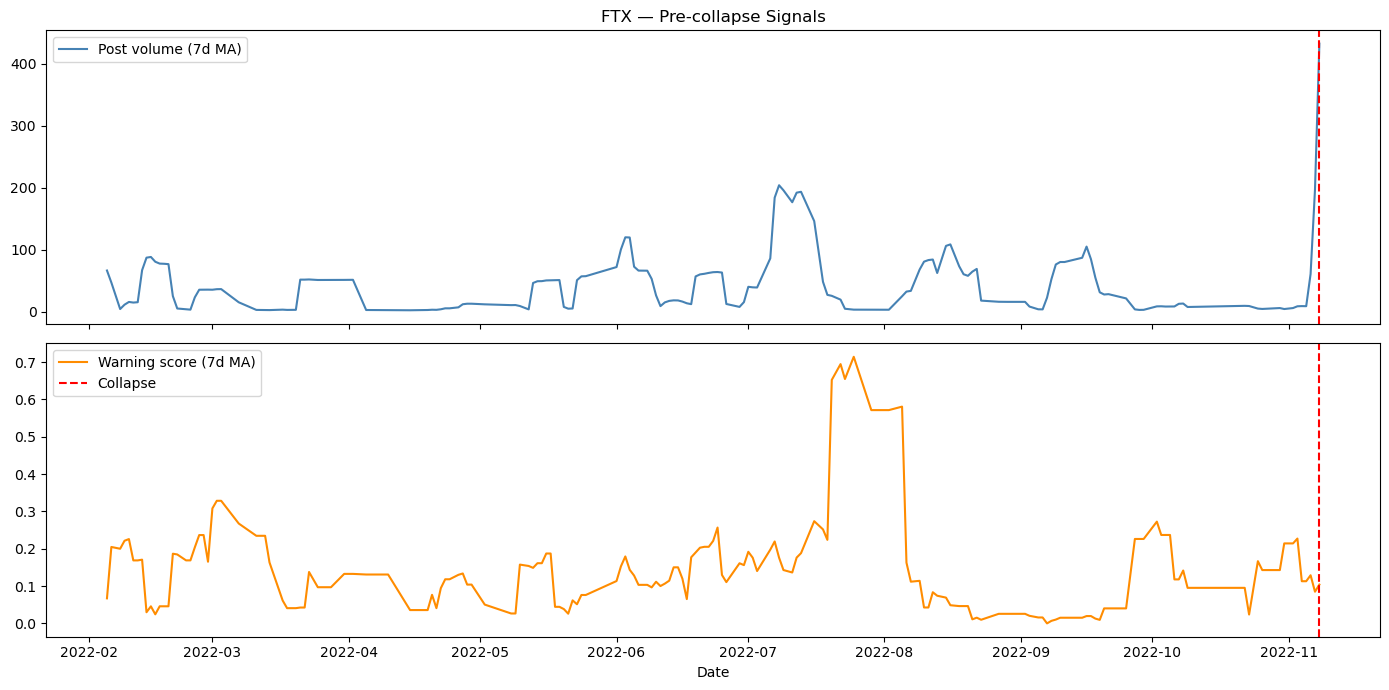

  FTX: first warning surge 272 days before collapse


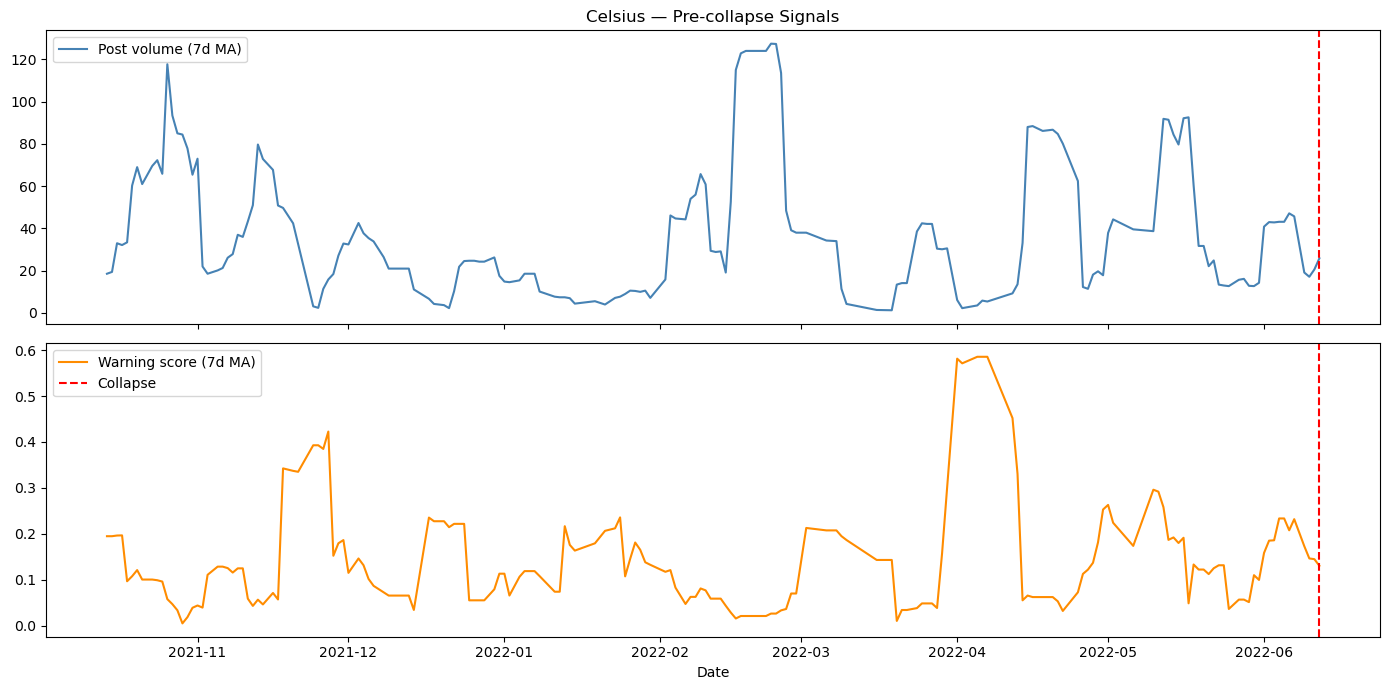

  Celsius: first warning surge 206 days before collapse


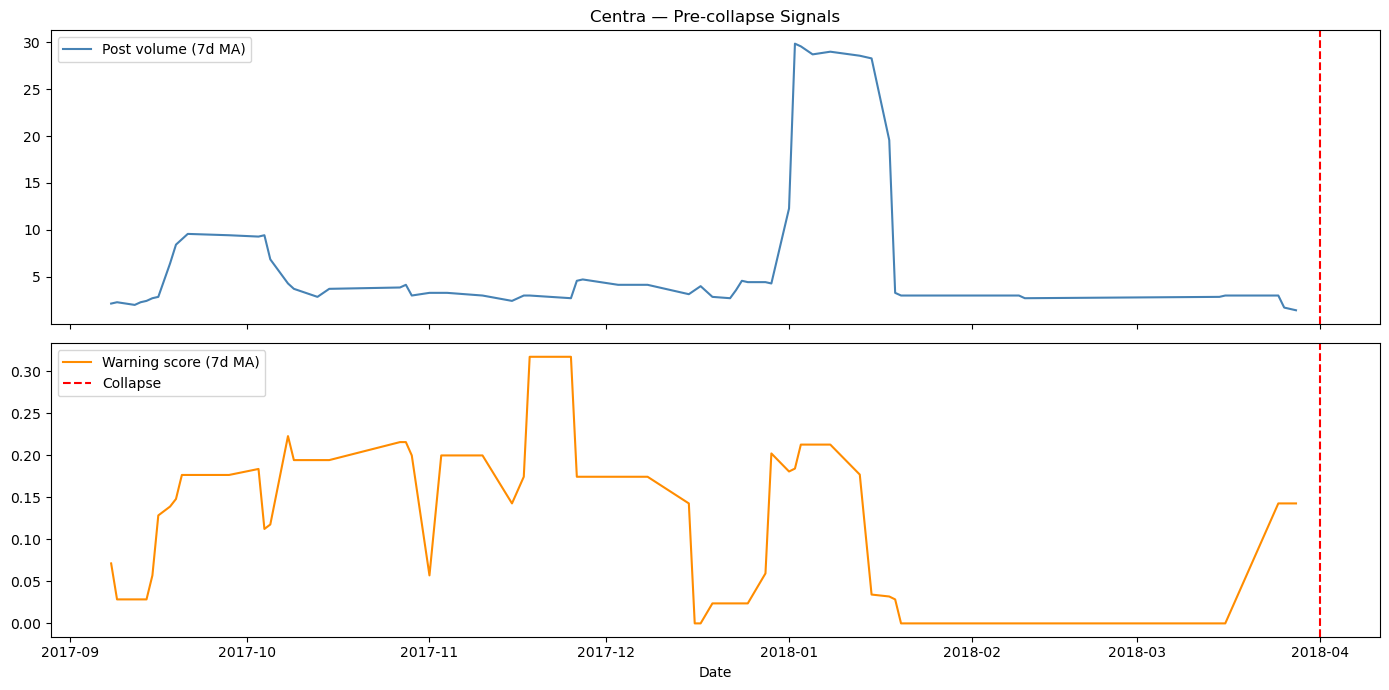

  Centra: first warning surge 134 days before collapse


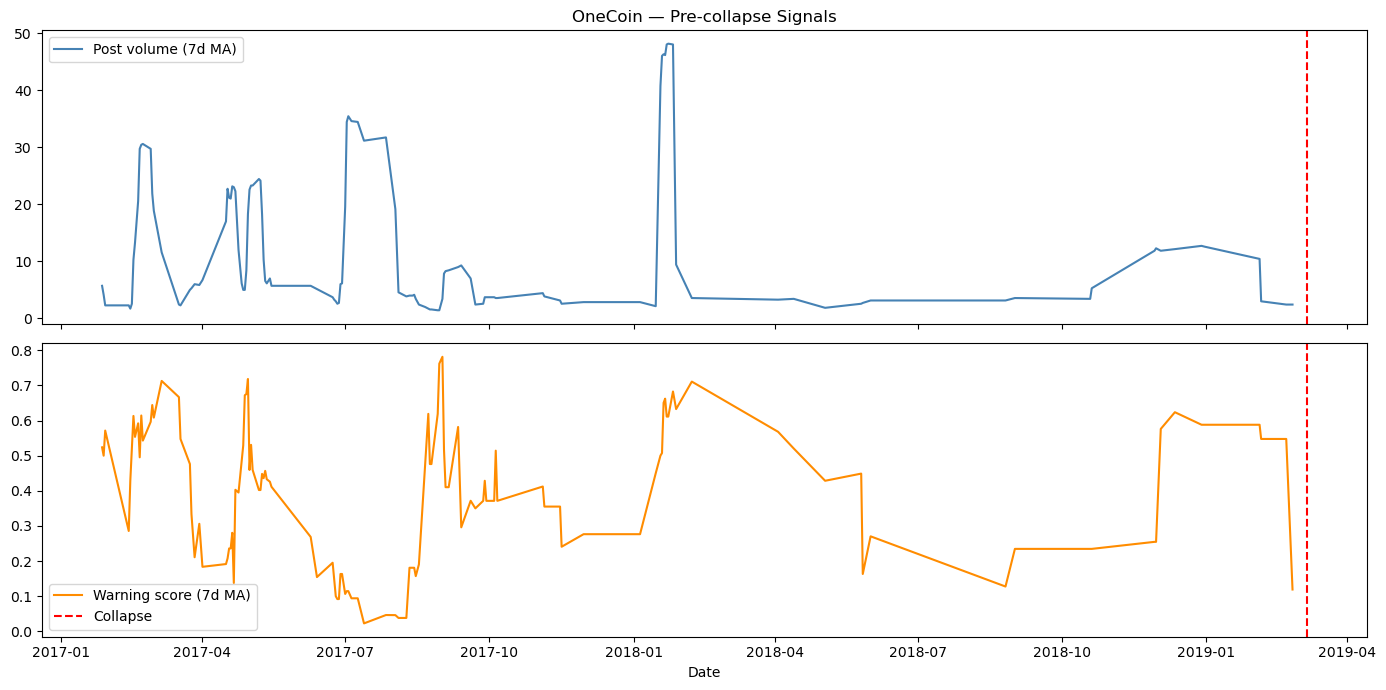

  OneCoin: first warning surge 748 days before collapse

[4b] Fraud taxonomy classifier …


Device set to use cpu



[4c] Survival analysis (time-to-collapse) …


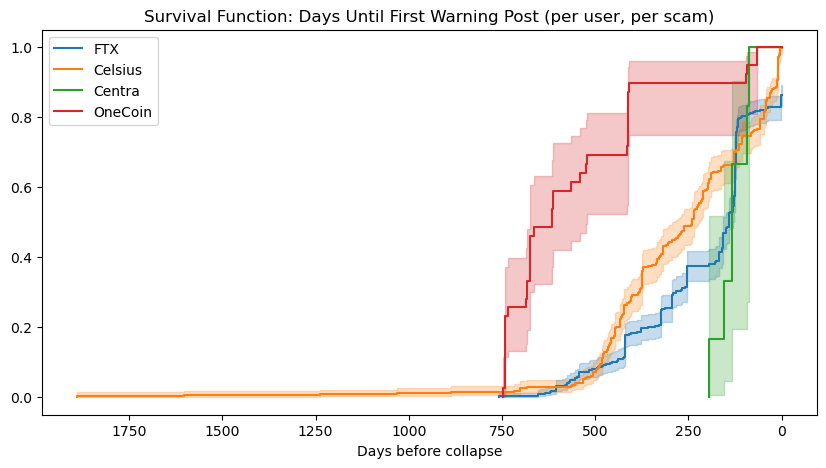


[4d] Risk scoring pipeline …

Risk Classifier (Logistic Regression):
              precision    recall  f1-score   support

     Celsius       0.65      0.27      0.38     11447
      Centra       0.47      0.04      0.07       492
         FTX       0.65      0.92      0.76     19374
     OneCoin       0.76      0.14      0.24      1214

    accuracy                           0.65     32527
   macro avg       0.63      0.34      0.36     32527
weighted avg       0.65      0.65      0.60     32527

  → models saved

ALL DONE — outputs saved to: C:\Users\User\Desktop\New folder\Reddit Data\outputs


In [44]:
if __name__ == "__main__":
    import argparse

    parser = argparse.ArgumentParser(description="Crypto Scam Full Analysis Pipeline")
    parser.add_argument(
        "--tracks", nargs="+",
        choices=["1", "2", "3", "4", "5", "6", "7", "8", "all"],
        default=["all"],
        help="Which analysis tracks to run (e.g. --tracks 1 3 5)"
    )
    parser.add_argument("--data-dir", type=str, default=".",
                        help="Directory containing the five CSV files")
    args, unknown = parser.parse_known_args()
    DATA_DIR = Path(args.data_dir)

    print("Loading data …")
    df_reddit = load_reddit(min_words=5)
    df_btc    = load_bitcointalk(min_words=5)
    print(f"Reddit: {len(df_reddit):,} rows | Bitcointalk: {len(df_btc):,} rows")

    run_all = "all" in args.tracks
    tracks  = args.tracks

    # if run_all or "1" in tracks:
    #     df_reddit, topic_model = track1_topic_modelling(df_reddit)

    # if run_all or "2" in tracks:
    #     df_reddit = track2_emotion_stance(df_reddit)

    # if run_all or "3" in tracks:
    #     graphs = track3_network_analysis(df_reddit)

    if run_all or "4" in tracks:
        df_features = track4_early_warning(df_reddit)

    # if run_all or "5" in tracks:
    #     fingerprints = track5_comparative(df_reddit, df_btc)

    # if run_all or "6" in tracks:
    #     ent_df = track6_knowledge_graph(df_reddit)

    # if run_all or "7" in tracks:
    #     track7_stylometrics(df_reddit)

    # if run_all or "8" in tracks:
    #     track8_enrichment(df_reddit)

    print("\n" + "="*60)
    print(f"ALL DONE — outputs saved to: {OUTPUT_DIR.resolve()}")
    print("="*60)


# =============================================================================
#  TRACK 5 — CROSS-PLATFORM & CROSS-SCAM COMPARATIVE ANALYSIS
# =============================================================================


In [45]:
def track5_comparative(df: pd.DataFrame, btc_df: pd.DataFrame):
    """
    5a. Bitcointalk vs Reddit discourse comparison
    5b. Scam-type linguistic fingerprints
    5c. Victim language comparison (Celsius vs FTX)
    5d. Event-aligned narrative analysis
    """
    print("\n" + "="*60)
    print("TRACK 5 — COMPARATIVE ANALYSIS")
    print("="*60)

    from sklearn.feature_extraction.text import TfidfVectorizer
    from wordcloud import WordCloud

    # ── 5a. Reddit vs Bitcointalk ─────────────────────────────────────────────
    print("\n[5a] Reddit vs Bitcointalk discourse …")

    reddit_text = df["clean_text"].sample(min(5000, len(df)), random_state=0).str.cat(sep=" ")
    btc_text    = btc_df["clean_text"].str.cat(sep=" ")

    # TF-IDF distinctive terms
    platform_texts  = [reddit_text, btc_text]
    platform_labels = ["Reddit", "Bitcointalk"]
    tfidf_plat = TfidfVectorizer(max_features=3000, stop_words="english", ngram_range=(1, 2))
    plat_matrix = tfidf_plat.fit_transform(platform_texts)
    feature_names = tfidf_plat.get_feature_names_out()

    for idx, label in enumerate(platform_labels):
        top_idx    = plat_matrix[idx].toarray()[0].argsort()[-20:][::-1]
        top_terms  = [(feature_names[i], plat_matrix[idx, i]) for i in top_idx]
        print(f"\n  Top distinctive terms — {label}:")
        for term, score in top_terms:
            print(f"    {term:30s} {score:.4f}")

    # Vocabulary richness comparison
    reddit_tokens = reddit_text.split()
    btc_tokens    = btc_text.split()
    print(f"\n  Reddit    — vocab size: {len(set(reddit_tokens)):,}, "
          f"avg word length: {np.mean([len(w) for w in reddit_tokens]):.2f}")
    print(f"  Bitcointalk — vocab size: {len(set(btc_tokens)):,}, "
          f"avg word length: {np.mean([len(w) for w in btc_tokens]):.2f}")

    # Word clouds side by side
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    for ax, text_, label in zip(axes, [reddit_text, btc_text], ["Reddit", "Bitcointalk"]):
        wc = WordCloud(width=600, height=400, background_color="white",
                       max_words=100, colormap="RdYlBu").generate(text_)
        ax.imshow(wc, interpolation="bilinear")
        ax.set_title(label, fontsize=13)
        ax.axis("off")
    plt.suptitle("Reddit vs Bitcointalk — Vocabulary Word Clouds")
    save_fig(fig, "wordcloud_platform_comparison")

    # Bitcointalk board distribution
    btc_boards = btc_df["board"].value_counts()
    fig2, ax2 = plt.subplots(figsize=(8, 4))
    btc_boards.plot(kind="bar", color="teal", ax=ax2)
    ax2.set_title("Bitcointalk: Posts per Board")
    ax2.tick_params(axis="x", rotation=40)
    plt.tight_layout()
    save_fig(fig2, "bitcointalk_board_distribution")

    # ── 5b. Scam-type Linguistic Fingerprints ─────────────────────────────────
    print("\n[5b] Linguistic fingerprints per scam …")

    SCAMS = ["FTX", "Celsius", "OneCoin", "Centra"]
    scam_texts = {
        scam: df[df["scam"] == scam]["clean_text"].str.cat(sep=" ")
        for scam in SCAMS
    }

    tfidf_scam = TfidfVectorizer(
        max_features=5000, stop_words="english",
        ngram_range=(1, 2), min_df=3
    )
    scam_matrix = tfidf_scam.fit_transform(list(scam_texts.values()))
    scam_features = tfidf_scam.get_feature_names_out()

    fingerprints = {}
    for idx, scam in enumerate(SCAMS):
        row      = scam_matrix[idx].toarray()[0]
        top_idx  = row.argsort()[-15:][::-1]
        top_terms = [(scam_features[i], row[i]) for i in top_idx]
        fingerprints[scam] = top_terms
        print(f"\n  {scam} linguistic fingerprint:")
        for term, score in top_terms:
            print(f"    {term:35s} {score:.4f}")

    # Heatmap of top terms across scams
    all_top_terms = list({t for scam_terms in fingerprints.values()
                          for t, _ in scam_terms[:10]})
    heatmap_data = []
    for scam in SCAMS:
        term_dict = dict(fingerprints[scam])
        row = [term_dict.get(t, 0) for t in all_top_terms]
        heatmap_data.append(row)
    heat_df = pd.DataFrame(heatmap_data, index=SCAMS, columns=all_top_terms)
    fig3, ax3 = plt.subplots(figsize=(16, 5))
    sns.heatmap(heat_df, annot=False, cmap="YlOrRd", ax=ax3, linewidths=0.3)
    ax3.set_title("Linguistic Fingerprints Heatmap (TF-IDF)")
    ax3.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    save_fig(fig3, "linguistic_fingerprints_heatmap")

    # ── 5c. Victim Language Comparison ───────────────────────────────────────
    print("\n[5c] Victim language comparison (Celsius vs FTX) …")

    VICTIM_KEYWORDS = [
        "lost", "lost everything", "lost my savings", "ruined", "destroyed",
        "can't pay", "mortgage", "retirement", "life savings", "suicidal",
        "devastated", "heartbroken", "betrayed", "trust", "how could they",
        "where is my money", "give me back", "class action", "lawsuit"
    ]

    for scam in ["FTX", "Celsius"]:
        sub = df[df["scam"] == scam]
        victim_posts = sub[sub["clean_text"].str.lower().str.contains(
            "|".join(VICTIM_KEYWORDS[:8]), na=False
        )]
        print(f"\n  {scam}: {len(victim_posts):,} victim-language posts "
              f"({len(victim_posts)/len(sub)*100:.1f}%)")

        # Victim language intensity over time
        victim_posts_copy = victim_posts.copy()
        victim_posts_copy["month"] = victim_posts_copy["timestamp_utc"].dt.to_period("M").astype(str)
        monthly = victim_posts_copy.groupby("month").size()
        fig4, ax4 = plt.subplots(figsize=(12, 4))
        ax4.bar(monthly.index, monthly.values, color="crimson", alpha=0.7)
        ax4.set_title(f"{scam} — Victim Language Posts per Month")
        ax4.tick_params(axis="x", rotation=45)
        plt.tight_layout()
        save_fig(fig4, f"victim_language_{scam}")

    # ── 5d. Event-aligned Narrative ──────────────────────────────────────────
    print("\n[5d] Event-aligned narrative analysis …")

    fig5, axes5 = plt.subplots(len(COLLAPSE_DATES), 1,
                                figsize=(14, 4 * len(COLLAPSE_DATES)))
    for ax, (scam, collapse_str) in zip(axes5, COLLAPSE_DATES.items()):
        if scam not in df["scam"].unique():
            ax.set_visible(False)
            continue
        sub      = df[df["scam"] == scam].copy()
        collapse = pd.Timestamp(collapse_str)
        sub      = sub[sub["timestamp_utc"].between(
            collapse - pd.Timedelta(days=180),
            collapse + pd.Timedelta(days=180)
        )]
        sub["date"] = sub["timestamp_utc"].dt.date
        daily_vol   = sub.groupby("date").size()
        ax.fill_between(daily_vol.index, daily_vol.values, alpha=0.3, color="steelblue")
        ax.plot(daily_vol.index, daily_vol.values, lw=1.5, color="steelblue")
        ax.axvline(collapse.date(), color="red", linestyle="--", lw=2,
                   label=f"{scam} collapse")
        ax.set_title(f"{scam} — 180-day narrative window")
        ax.legend()
        ax.xaxis.set_major_locator(mdates.MonthLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)
    plt.suptitle("Reddit Activity Around Each Scam Collapse Event", fontsize=13)
    plt.tight_layout()
    save_fig(fig5, "event_aligned_narrative")

    return fingerprints

Loading data …
Reddit: 162,634 rows | Bitcointalk: 2,303 rows

TRACK 5 — COMPARATIVE ANALYSIS

[5a] Reddit vs Bitcointalk discourse …

  Top distinctive terms — Reddit:
    crypto                         0.3155
    just                           0.2879
    people                         0.2667
    like                           0.2479
    money                          0.2052
    don                            0.1908
    bitcoin                        0.1647
    btc                            0.1451
    ftx                            0.1319
    think                          0.1194
    time                           0.1190
    market                         0.1149
    know                           0.1130
    good                           0.1088
    going                          0.0975
    celsius                        0.0963
    way                            0.0926
    use                            0.0854
    coins                          0.0820
    make                         

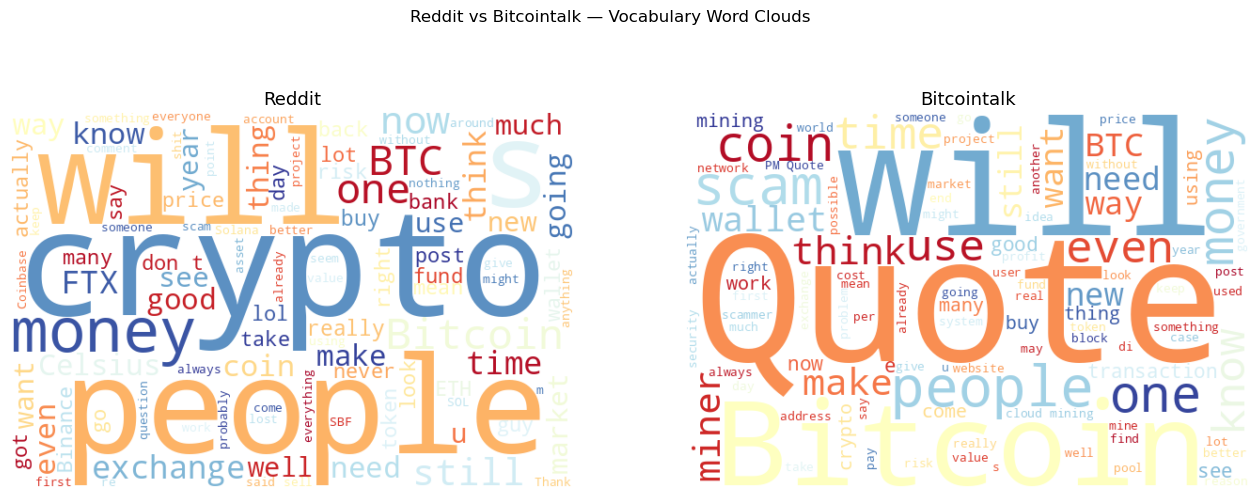

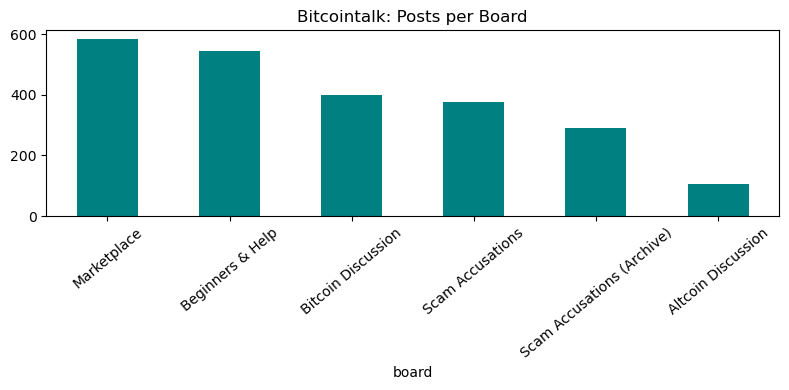


[5b] Linguistic fingerprints per scam …

  FTX linguistic fingerprint:
    just                                0.3035
    crypto                              0.2844
    like                                0.2562
    people                              0.2550
    ftx                                 0.2225
    money                               0.2053
    don                                 0.1819
    bitcoin                             0.1557
    time                                0.1358
    think                               0.1335
    btc                                 0.1180
    market                              0.1124
    going                               0.1109
    know                                0.1094
    good                                0.1052

  Celsius linguistic fingerprint:
    crypto                              0.3043
    just                                0.2814
    like                                0.2538
    people                              0.2514


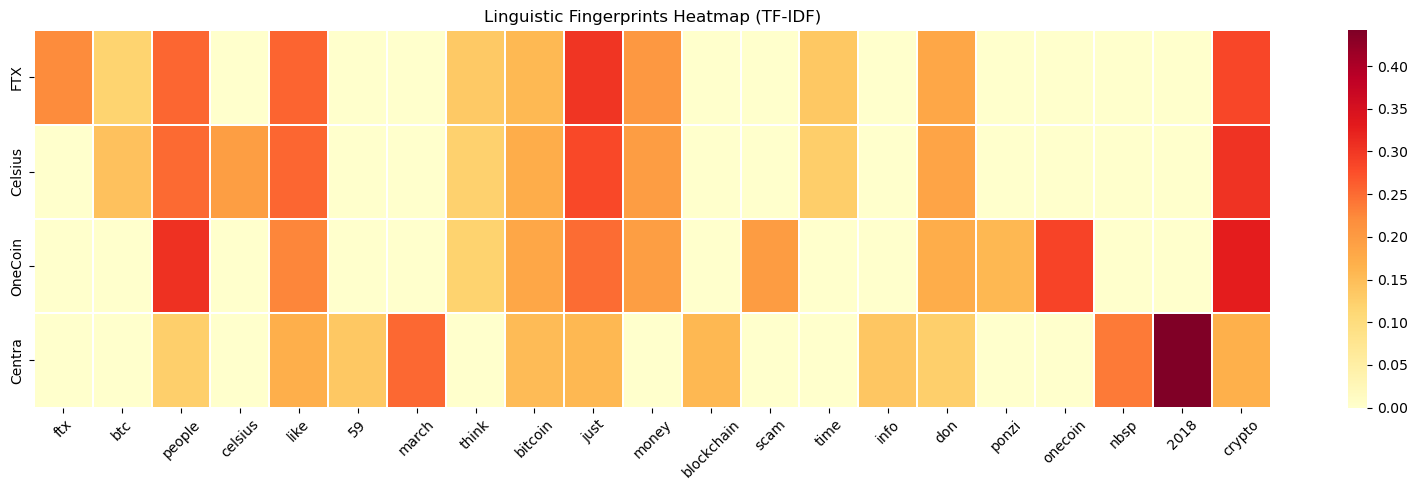


[5c] Victim language comparison (Celsius vs FTX) …

  FTX: 1,908 victim-language posts (2.0%)


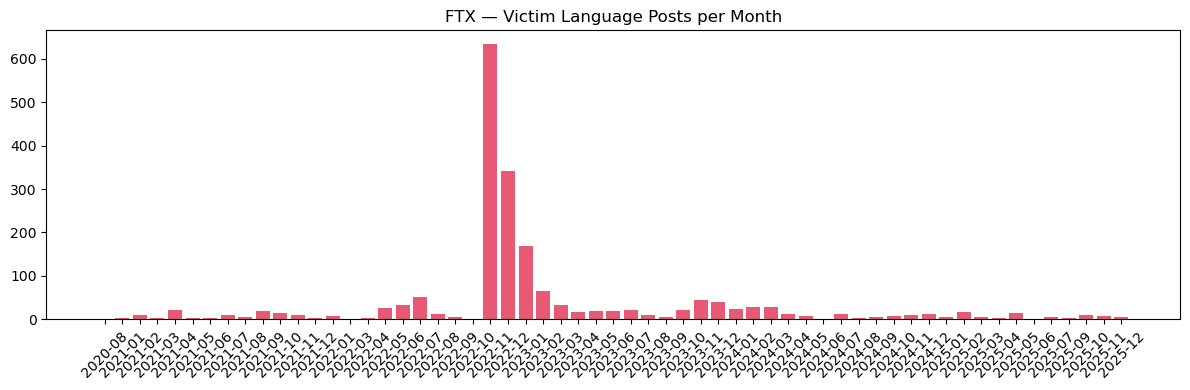


  Celsius: 1,490 victim-language posts (2.6%)


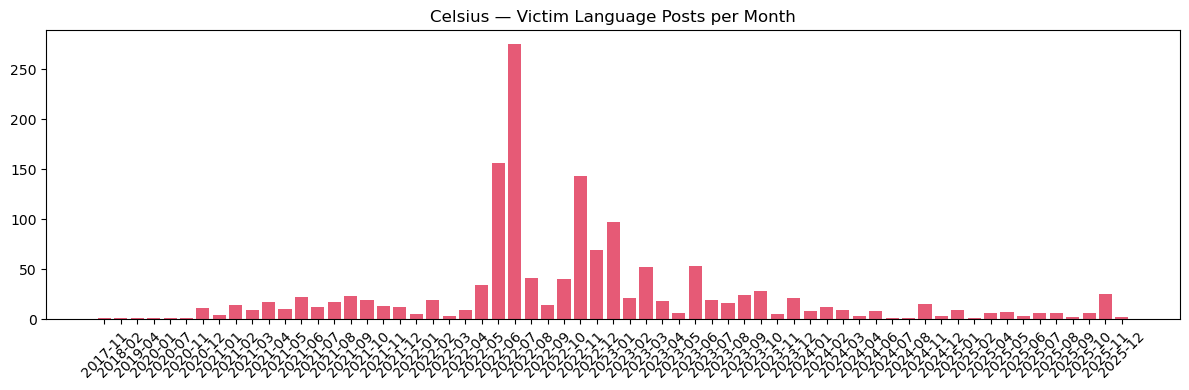


[5d] Event-aligned narrative analysis …


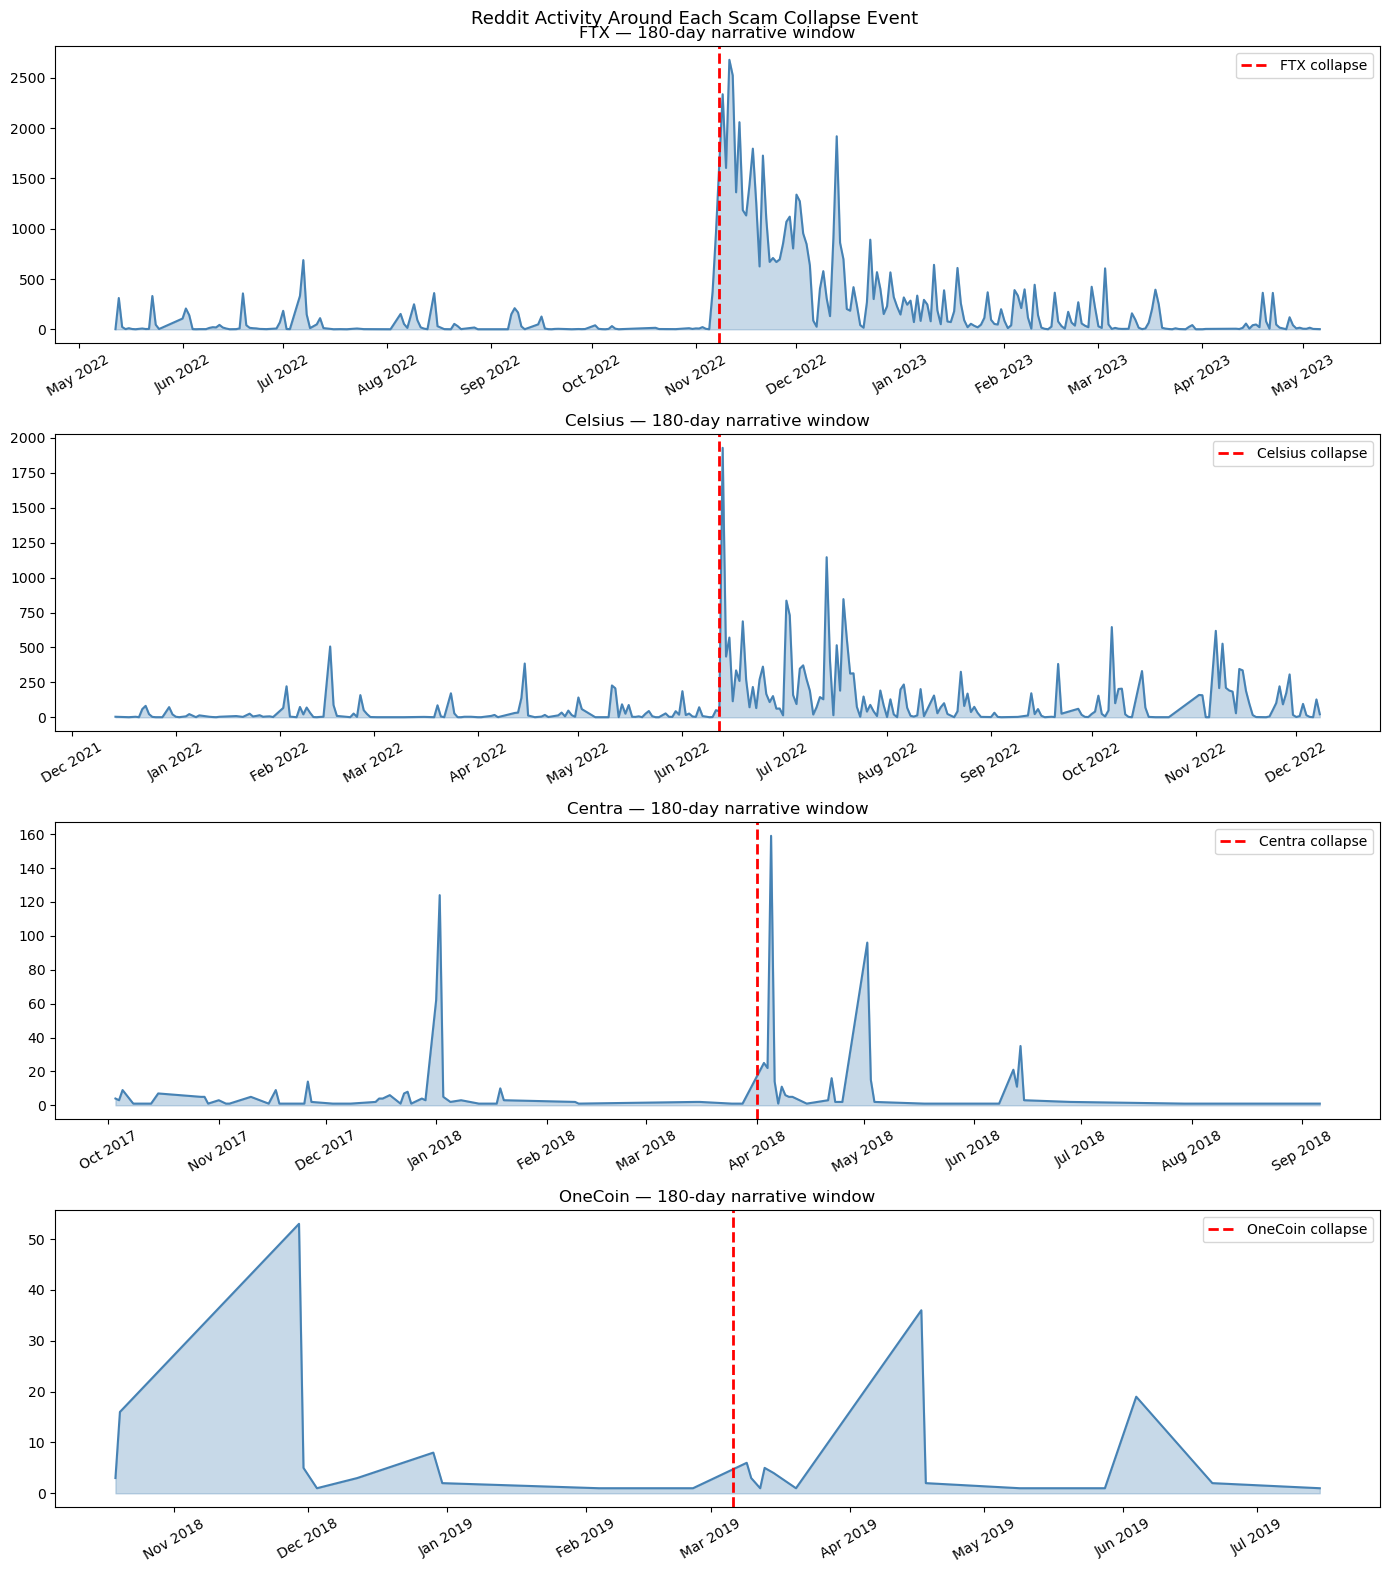


ALL DONE — outputs saved to: C:\Users\User\Desktop\New folder\Reddit Data\outputs


In [46]:
if __name__ == "__main__":
    import argparse

    parser = argparse.ArgumentParser(description="Crypto Scam Full Analysis Pipeline")
    parser.add_argument(
        "--tracks", nargs="+",
        choices=["1", "2", "3", "4", "5", "6", "7", "8", "all"],
        default=["all"],
        help="Which analysis tracks to run (e.g. --tracks 1 3 5)"
    )
    parser.add_argument("--data-dir", type=str, default=".",
                        help="Directory containing the five CSV files")
    args, unknown = parser.parse_known_args()
    DATA_DIR = Path(args.data_dir)

    print("Loading data …")
    df_reddit = load_reddit(min_words=5)
    df_btc    = load_bitcointalk(min_words=5)
    print(f"Reddit: {len(df_reddit):,} rows | Bitcointalk: {len(df_btc):,} rows")

    run_all = "all" in args.tracks
    tracks  = args.tracks

    # if run_all or "1" in tracks:
    #     df_reddit, topic_model = track1_topic_modelling(df_reddit)

    # if run_all or "2" in tracks:
    #     df_reddit = track2_emotion_stance(df_reddit)

    # if run_all or "3" in tracks:
    #     graphs = track3_network_analysis(df_reddit)

    # if run_all or "4" in tracks:
    #     df_features = track4_early_warning(df_reddit)

    if run_all or "5" in tracks:
        fingerprints = track5_comparative(df_reddit, df_btc)

    # if run_all or "6" in tracks:
    #     ent_df = track6_knowledge_graph(df_reddit)

    # if run_all or "7" in tracks:
    #     track7_stylometrics(df_reddit)

    # if run_all or "8" in tracks:
    #     track8_enrichment(df_reddit)

    print("\n" + "="*60)
    print(f"ALL DONE — outputs saved to: {OUTPUT_DIR.resolve()}")
    print("="*60)


# =============================================================================
#  TRACK 6 — KNOWLEDGE GRAPH & ENTITY EXTRACTION
# =============================================================================

In [52]:
import sys
!{sys.executable} -m pip install spacy
!{sys.executable} -m spacy download en_core_web_sm

  Using cached spacy-3.8.13.tar.gz (1.3 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'error'


  error: subprocess-exited-with-error
  
  × installing build dependencies for spacy did not run successfully.
  │ exit code: 1
  ╰─> [14 lines of output]
        Using cached setuptools-82.0.1-py3-none-any.whl.metadata (6.5 kB)
        Using cached cython-3.2.5-cp39-cp39-win_amd64.whl.metadata (7.3 kB)
        Using cached cymem-2.0.13-cp39-cp39-win_amd64.whl.metadata (9.9 kB)
        Using cached preshed-3.0.13-cp39-cp39-win_amd64.whl.metadata (5.4 kB)
        Using cached murmurhash-1.0.15-cp39-cp39-win_amd64.whl.metadata (2.3 kB)
      ERROR: Ignored the following yanked versions: 6.10.4.dev0, 7.4.4, 8.3.5
      ERROR: Ignored the following versions that require a different python version: 8.3.10 Requires-Python >=3.10,<3.15; 8.3.11 Requires-Python >=3.10,<3.15; 8.3.12 Requires-Python >=3.10,<3.15; 8.3.13 Requires-Python >=3.10,<3.15
      ERROR: Could not find a version that satisfies the requirement thinc<8.4.0,>=8.3.12 (from versions: 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.41, 1.42, 1.

In [ ]:
def track6_knowledge_graph(df: pd.DataFrame):
    """
    6a. Named Entity Recognition (spaCy)
    6b. Crypto scam knowledge graph (NetworkX + PyVis)
    6c. Causal chain extraction
    """
    print("\n" + "="*60)
    print("TRACK 6 — KNOWLEDGE GRAPH & NER")
    print("="*60)

    import spacy
    try:
        nlp = spacy.load("en_core_web_sm")
    except OSError:
        print("  Downloading spaCy model …")
        os.system("python -m spacy download en_core_web_sm")
        nlp = spacy.load("en_core_web_sm")

    # ── 6a. NER ───────────────────────────────────────────────────────────────
    print("\n[6a] Named Entity Recognition …")

    # Process a sample — spaCy is slow on large corpora
    ner_sample = df.sample(min(10_000, len(df)), random_state=4).copy()
    entity_records = []

    # Batch processing for speed
    PIPE_BATCH = 256
    texts = ner_sample["clean_text"].tolist()
    ids   = ner_sample["scam"].tolist()

    for i, doc in enumerate(nlp.pipe(texts, batch_size=PIPE_BATCH)):
        scam_label = ids[i]
        for ent in doc.ents:
            if ent.label_ in {"PERSON", "ORG", "MONEY", "DATE", "GPE", "PRODUCT"}:
                entity_records.append({
                    "entity_text":  ent.text.strip(),
                    "entity_label": ent.label_,
                    "scam":         scam_label,
                })
        if i % 1000 == 0:
            print(f"  NER: {i}/{len(texts)}")

    ent_df = pd.DataFrame(entity_records)
    ent_df.to_csv(OUTPUT_DIR / "ner_entities.csv", index=False)
    print(f"  Extracted {len(ent_df):,} entities")

    # Top entities per type and scam
    for label in ["PERSON", "ORG", "MONEY"]:
        print(f"\n  Top {label} entities:")
        top = ent_df[ent_df["entity_label"] == label]["entity_text"].value_counts().head(15)
        print(top.to_string())

    # Entity frequency bar chart per type
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, etype in zip(axes, ["PERSON", "ORG", "MONEY"]):
        sub = ent_df[ent_df["entity_label"] == etype]["entity_text"].value_counts().head(15)
        ax.barh(sub.index, sub.values, color="steelblue")
        ax.set_title(f"Top {etype} Entities")
        ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

    # ── 6b. Knowledge Graph ───────────────────────────────────────────────────
    print("\n[6b] Building knowledge graph …")
    import networkx as nx

    KG = nx.Graph()

    # Nodes: scam names + top entities
    for scam in df["scam"].unique():
        KG.add_node(scam, node_type="scam")

    # Add top entities as nodes; connect them to their scam
    for scam in df["scam"].unique():
        scam_ents = ent_df[ent_df["scam"] == scam]
        for etype in ["PERSON", "ORG"]:
            top_ents = scam_ents[scam_ents["entity_label"] == etype][
                "entity_text"
            ].value_counts().head(10)
            for entity, count in top_ents.items():
                if len(entity) < 3:
                    continue
                KG.add_node(entity, node_type=etype)
                if KG.has_edge(scam, entity):
                    KG[scam][entity]["weight"] += count
                else:
                    KG.add_edge(scam, entity, weight=count, relation="mentioned_in")

    # Co-occurrence edges between entities
    for doc_ents in ent_df.groupby(ent_df.index // 1)["entity_text"]:
        # (Simplified: entities that appear in same document)
        pass  # extend here if needed

    print(f"  Knowledge graph: {KG.number_of_nodes()} nodes, {KG.number_of_edges()} edges")
    nx.write_graphml(KG, str(OUTPUT_DIR / "scam_knowledge_graph.graphml"))

    # Visualise with PyVis if available
    try:
        from pyvis.network import Network as PyvisNet
        import tempfile, os
        from IPython.display import display, HTML

        pyvis_kg = PyvisNet(height="700px", width="100%", notebook=False)
        color_map = {"scam": "#e74c3c", "PERSON": "#3498db", "ORG": "#2ecc71"}
        for node, attrs in KG.nodes(data=True):
            pyvis_kg.add_node(
                str(node),
                label=str(node),
                color=color_map.get(attrs.get("node_type", ""), "#95a5a6"),
                size=20 if attrs.get("node_type") == "scam" else 10
            )
        for u, v, attrs in KG.edges(data=True):
            pyvis_kg.add_edge(str(u), str(v), value=attrs.get("weight", 1))
        # pyvis_kg.save_graph(str(OUTPUT_DIR / "knowledge_graph.html"))
        # print("  → saved knowledge_graph.html")
        tmp_path = os.path.join(tempfile.gettempdir(), "knowledge_graph.html")
        pyvis_kg.save_graph(tmp_path)
        display(HTML(open(tmp_path, encoding="utf-8").read()))
    except ImportError:
        pass

    # NetworkX spring layout plot
    fig2, ax2 = plt.subplots(figsize=(14, 10))
    pos = nx.spring_layout(KG, k=2, seed=42)
    node_colors = [
        "#e74c3c" if KG.nodes[n].get("node_type") == "scam" else
        "#3498db" if KG.nodes[n].get("node_type") == "PERSON" else "#2ecc71"
        for n in KG.nodes()
    ]
    nx.draw_networkx(
        KG, pos, ax=ax2, node_color=node_colors,
        node_size=[500 if KG.nodes[n].get("node_type")=="scam" else 100 for n in KG.nodes()],
        font_size=7, alpha=0.8, edge_color="#ccc"
    )
    ax2.set_title("Crypto Scam Knowledge Graph")
    ax2.axis("off")
    # save_fig(fig2, "knowledge_graph_networkx")
    plt.show()

    # ── 6c. Causal Chain Extraction ───────────────────────────────────────────
    print("\n[6c] Causal chain extraction …")

    # Patterns: "X caused/led to/resulted in Y"
    CAUSAL_PATTERNS = [
        r"(\w[\w\s]+?)\s+(?:caused|led to|resulted in|triggered|due to|because of)\s+([\w\s]+)",
        r"(?:because|since|as a result of)\s+([\w\s]+),\s+([\w\s]+)",
        r"([\w\s]+)\s+(?:collapsed|failed|went bankrupt)\s+(?:because|due to|after)\s+([\w\s]+)",
    ]

    causal_records = []
    causal_sample = df.sample(min(5000, len(df)), random_state=5)
    for _, row in causal_sample.iterrows():
        text = row["clean_text"].lower()
        for pat in CAUSAL_PATTERNS:
            matches = re.findall(pat, text)
            for match in matches:
                causal_records.append({
                    "scam":   row["scam"],
                    "cause":  match[0].strip()[:80],
                    "effect": match[1].strip()[:80],
                    "text":   row["clean_text"][:200],
                })

    causal_df = pd.DataFrame(causal_records)
    causal_df.to_csv(OUTPUT_DIR / "causal_chains.csv", index=False)
    print(f"  Extracted {len(causal_df):,} causal relations")
    print(causal_df.head(10).to_string())

    return ent_df


In [51]:
if __name__ == "__main__":
    import argparse

    parser = argparse.ArgumentParser(description="Crypto Scam Full Analysis Pipeline")
    parser.add_argument(
        "--tracks", nargs="+",
        choices=["1", "2", "3", "4", "5", "6", "7", "8", "all"],
        default=["all"],
        help="Which analysis tracks to run (e.g. --tracks 1 3 5)"
    )
    parser.add_argument("--data-dir", type=str, default=".",
                        help="Directory containing the five CSV files")
    args, unknown = parser.parse_known_args()
    DATA_DIR = Path(args.data_dir)

    print("Loading data …")
    df_reddit = load_reddit(min_words=5)
    df_btc    = load_bitcointalk(min_words=5)
    print(f"Reddit: {len(df_reddit):,} rows | Bitcointalk: {len(df_btc):,} rows")

    run_all = "all" in args.tracks
    tracks  = args.tracks

    # if run_all or "1" in tracks:
    #     df_reddit, topic_model = track1_topic_modelling(df_reddit)

    # if run_all or "2" in tracks:
    #     df_reddit = track2_emotion_stance(df_reddit)

    # if run_all or "3" in tracks:
    #     graphs = track3_network_analysis(df_reddit)

    # if run_all or "4" in tracks:
    #     df_features = track4_early_warning(df_reddit)

    # if run_all or "5" in tracks:
    #     fingerprints = track5_comparative(df_reddit, df_btc)

    if run_all or "6" in tracks:
        ent_df = track6_knowledge_graph(df_reddit)

    # if run_all or "7" in tracks:
    #     track7_stylometrics(df_reddit)

    # if run_all or "8" in tracks:
    #     track8_enrichment(df_reddit)

    print("\n" + "="*60)
    print(f"ALL DONE — outputs saved to: {OUTPUT_DIR.resolve()}")
    print("="*60)


Loading data …
Reddit: 162,634 rows | Bitcointalk: 2,303 rows

TRACK 6 — KNOWLEDGE GRAPH & NER


ModuleNotFoundError: No module named 'spacy'

# =============================================================================
#  TRACK 7 — LINGUISTIC & STYLOMETRIC ANALYSIS
# =============================================================================

In [ ]:
def track7_stylometrics(df: pd.DataFrame):
    """
    7a. Readability & complexity scoring
    7b. Psycholinguistic features (LIWC-style)
    7c. Lexical shift over time (Word2Vec)
    """
    print("\n" + "="*60)
    print("TRACK 7 — LINGUISTIC & STYLOMETRIC ANALYSIS")
    print("="*60)

    import textstat

    # ── 7a. Readability ───────────────────────────────────────────────────────
    print("\n[7a] Readability scoring …")

    def compute_readability(text):
        if len(text.split()) < 10:
            return {}
        try:
            return {
                "flesch_reading_ease":      textstat.flesch_reading_ease(text),
                "flesch_kincaid_grade":     textstat.flesch_kincaid_grade(text),
                "gunning_fog":              textstat.gunning_fog(text),
                "smog_index":               textstat.smog_index(text),
                "automated_readability":    textstat.automated_readability_index(text),
                "type_token_ratio":         len(set(text.lower().split())) /
                                            max(len(text.split()), 1),
                "avg_sentence_length":      textstat.avg_sentence_length(text),
                "avg_syllables_per_word":   textstat.avg_syllables_per_word(text),
            }
        except Exception:
            return {}

    read_sample = df.sample(min(20_000, len(df)), random_state=6).copy()
    readability_records = read_sample["clean_text"].apply(compute_readability)
    read_df = pd.DataFrame(readability_records.tolist())
    read_sample = pd.concat([read_sample.reset_index(drop=True), read_df], axis=1)

    # Compare readability across scams
    for metric in ["flesch_reading_ease", "type_token_ratio", "avg_sentence_length"]:
        fig, ax = plt.subplots(figsize=(9, 4))
        for scam in read_sample["scam"].unique():
            vals = read_sample[read_sample["scam"] == scam][metric].dropna()
            ax.hist(vals, bins=40, alpha=0.5, label=scam, density=True)
        ax.set_title(f"{metric} distribution per scam")
        ax.legend()
        save_fig(fig, f"readability_{metric}")

    # By post type: scam promotion vs warning
    PROMO_KW   = ["moon", "guaranteed", "passive income", "100x"]
    WARNING_KW = ["warning", "scam", "fraud", "withdraw", "bankrupt"]
    read_sample["text_type"] = "neutral"
    read_sample.loc[read_sample["clean_text"].str.lower().str.contains(
        "|".join(PROMO_KW), na=False), "text_type"] = "promotion"
    read_sample.loc[read_sample["clean_text"].str.lower().str.contains(
        "|".join(WARNING_KW), na=False), "text_type"] = "warning"

    readability_by_type = read_sample.groupby("text_type")[
        ["flesch_reading_ease", "type_token_ratio", "avg_sentence_length"]
    ].mean()
    print("\nReadability by post type:")
    print(readability_by_type.to_string())
    read_sample.to_csv(OUTPUT_DIR / "readability_scores.csv", index=False)

    # ── 7b. Psycholinguistic Features ─────────────────────────────────────────
    print("\n[7b] Psycholinguistic features (LIWC-style) …")

    LIWC_DICTS = {
        "certainty":       ["definitely", "certainly", "absolutely", "always", "never",
                            "guaranteed", "proof", "fact", "obviously", "clearly"],
        "anxiety":         ["worried", "scared", "fear", "panic", "terrified", "nervous",
                            "anxious", "stress", "concerned", "uncertain"],
        "social":          ["community", "people", "everyone", "together", "we", "our",
                            "group", "team", "family", "friends"],
        "money":           ["money", "profit", "invest", "return", "earn", "loss",
                            "funds", "cash", "wallet", "withdraw"],
        "future_orient":   ["will", "shall", "going to", "soon", "plan", "expect",
                            "forecast", "predict", "future", "upcoming"],
        "anger":           ["angry", "furious", "outraged", "disgusting", "ridiculous",
                            "unacceptable", "disgusted", "hate", "livid", "infuriating"],
        "cognitive_proc":  ["think", "know", "consider", "maybe", "because", "reason",
                            "understand", "believe", "if", "though"],
        "positive_affect": ["happy", "great", "amazing", "love", "excited", "brilliant",
                            "excellent", "fantastic", "wonderful", "awesome"],
    }

    def liwc_scores(text, dicts):
        text_lower = text.lower().split()
        total = max(len(text_lower), 1)
        return {
            cat: sum(1 for w in text_lower if w in words) / total * 100
            for cat, words in dicts.items()
        }

    liwc_sample = df.sample(min(15_000, len(df)), random_state=7).copy()
    liwc_records = liwc_sample["clean_text"].apply(lambda t: liwc_scores(t, LIWC_DICTS))
    liwc_df      = pd.DataFrame(liwc_records.tolist())
    liwc_sample  = pd.concat([liwc_sample.reset_index(drop=True), liwc_df], axis=1)
    liwc_sample.to_csv(OUTPUT_DIR / "liwc_scores.csv", index=False)

    # Radar / spider chart per scam
    liwc_by_scam = liwc_sample.groupby("scam")[list(LIWC_DICTS.keys())].mean()
    fig2 = go.Figure()
    for scam in liwc_by_scam.index:
        vals = liwc_by_scam.loc[scam].tolist()
        cats = list(LIWC_DICTS.keys())
        fig2.add_trace(go.Scatterpolar(
            r=vals + [vals[0]], theta=cats + [cats[0]],
            fill="toself", name=scam, opacity=0.5
        ))
    fig2.update_layout(
        polar=dict(radialaxis=dict(visible=True)),
        title="Psycholinguistic Profile per Scam (LIWC-style)",
        showlegend=True
    )
    save_plotly(fig2, "liwc_radar_per_scam")

    # ── 7c. Lexical Shift (Word2Vec) ──────────────────────────────────────────
    print("\n[7c] Lexical shift over time (Word2Vec) …")
    import gensim
    from gensim.models import Word2Vec
    from nltk.tokenize import word_tokenize
    import nltk
    nltk.download("punkt", quiet=True)
    nltk.download("punkt_tab", quiet=True)

    FOCUS_WORDS = ["withdraw", "trust", "bankrupt", "safe", "scam", "invest", "risk"]

    for scam_name in ["FTX", "Celsius"]:
        sub = df[df["scam"] == scam_name].copy()
        sub = sub.sort_values("timestamp_utc")
        collapse = pd.Timestamp(COLLAPSE_DATES[scam_name])

        sub["phase"] = "pre-collapse"
        sub.loc[sub["timestamp_utc"] > collapse, "phase"] = "post-collapse"

        print(f"\n  {scam_name} — Word2Vec semantic shift:")
        phase_similar = {}
        for phase in ["pre-collapse", "post-collapse"]:
            phase_texts = sub[sub["phase"] == phase]["clean_text"].tolist()
            if len(phase_texts) < 100:
                continue
            sentences = [
                word_tokenize(t.lower()) for t in phase_texts if isinstance(t, str)
            ]
            model = Word2Vec(
                sentences, vector_size=100, window=5,
                min_count=5, workers=4, epochs=10
            )
            phase_similar[phase] = {}
            for word in FOCUS_WORDS:
                if word in model.wv:
                    similar = [w for w, _ in model.wv.most_similar(word, topn=5)]
                    phase_similar[phase][word] = similar
                    print(f"    [{phase}] '{word}' → {similar}")

        # Cosine similarity of word vectors between phases
        if len(phase_similar) == 2:
            print(f"\n  Semantic similarity shift for '{scam_name}':")


# =============================================================================
#  TRACK 8 — DATA ENRICHMENT & MULTIMODAL EXTENSION
# =============================================================================

def track8_enrichment(df: pd.DataFrame):
    """
    8a. Sentiment–price correlation (requires price CSV)
    8b. News & regulatory event alignment
    8c. Multi-platform expansion framework
    """
    print("\n" + "="*60)
    print("TRACK 8 — DATA ENRICHMENT")
    print("="*60)

    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

    analyzer = SentimentIntensityAnalyzer()

    def vader_score(text):
        if not isinstance(text, str) or len(text) < 5:
            return 0.0
        return analyzer.polarity_scores(text)["compound"]

    # ── 8a. Sentiment–Price Correlation ──────────────────────────────────────
    print("\n[8a] Sentiment–price correlation framework …")

    # Compute daily VADER sentiment for FTX and Celsius
    for scam in ["FTX", "Celsius"]:
        sub = df[df["scam"] == scam].copy()
        sub["vader_compound"] = sub["clean_text"].apply(vader_score)
        sub["date"] = sub["timestamp_utc"].dt.date

        daily_sentiment = sub.groupby("date").agg(
            avg_sentiment = ("vader_compound", "mean"),
            post_count    = ("id", "count"),
            neg_ratio     = ("vader_compound", lambda x: (x < -0.05).mean()),
        ).reset_index()
        daily_sentiment.to_csv(OUTPUT_DIR / f"daily_sentiment_{scam}.csv", index=False)
        print(f"  {scam}: daily sentiment saved — {len(daily_sentiment)} days")

    # Price correlation template:
    # If you have a price CSV with columns [date, close_price], run:
    #
    # price_df = pd.read_csv("ftx_price.csv")
    # price_df["date"] = pd.to_datetime(price_df["date"]).dt.date
    # merged = daily_sentiment.merge(price_df, on="date", how="inner")
    # correlation = merged["avg_sentiment"].corr(merged["close_price"])
    # print(f"Sentiment–price Pearson correlation: {correlation:.3f}")
    #
    # # Lead-lag analysis (does sentiment lead price by N days?)
    # for lag in range(-7, 8):
    #     lagged = merged["avg_sentiment"].shift(lag).corr(merged["close_price"])
    #     print(f"  Lag {lag:+d} days: r = {lagged:.3f}")

    # ── 8b. News & Regulatory Event Alignment ────────────────────────────────
    print("\n[8b] News & regulatory event alignment …")

    # Key events timeline — extend this with your own research
    EVENTS = {
        "FTX": [
            ("2022-11-02", "CoinDesk reports on Alameda balance sheet"),
            ("2022-11-06", "Binance announces FTT sell-off"),
            ("2022-11-08", "FTX halts withdrawals"),
            ("2022-11-11", "FTX files Chapter 11 bankruptcy"),
            ("2022-12-12", "SBF arrested in Bahamas"),
            ("2023-10-26", "SBF trial begins"),
        ],
        "Celsius": [
            ("2022-06-12", "Celsius freezes withdrawals"),
            ("2022-07-13", "Celsius files for bankruptcy"),
            ("2023-01-05", "CEO Alex Mashinsky resigns"),
            ("2023-07-13", "Mashinsky charged with fraud"),
        ],
        "OneCoin": [
            ("2017-11-01", "US DoJ indicts OneCoin promoters"),
            ("2019-03-06", "Ruja Ignatova placed on FBI most wanted"),
            ("2019-03-22", "Mark Scott arrested for laundering"),
        ],
        "Centra": [
            ("2018-04-01", "SEC charges Centra founders"),
            ("2018-04-02", "Founders arrested"),
        ],
    }

    for scam, events in EVENTS.items():
        if scam not in df["scam"].unique():
            continue
        sub = df[df["scam"] == scam].copy()
        sub["vader_compound"] = sub["clean_text"].apply(vader_score)
        sub["date"] = sub["timestamp_utc"].dt.date
        daily = sub.groupby("date").agg(
            avg_sentiment = ("vader_compound", "mean"),
            post_count    = ("id", "count"),
        ).reset_index()
        daily["date"] = pd.to_datetime(daily["date"])

        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
        ax1.plot(daily["date"], daily["post_count"], color="steelblue", lw=1)
        ax1.set_ylabel("Post Count")
        ax1.set_title(f"{scam} — Post Volume & Sentiment with Key Events")

        ax2.fill_between(daily["date"], daily["avg_sentiment"],
                         where=(daily["avg_sentiment"] >= 0),
                         color="green", alpha=0.4, label="Positive")
        ax2.fill_between(daily["date"], daily["avg_sentiment"],
                         where=(daily["avg_sentiment"] < 0),
                         color="red", alpha=0.4, label="Negative")
        ax2.axhline(0, color="black", lw=0.5)
        ax2.set_ylabel("VADER Sentiment")
        ax2.legend()

        for date_str, desc in events:
            event_date = pd.Timestamp(date_str)
            for ax in [ax1, ax2]:
                ax.axvline(event_date, color="orange", lw=1.5,
                           linestyle="--", alpha=0.8)
            ax1.annotate(desc, xy=(event_date, ax1.get_ylim()[1]),
                         fontsize=6, rotation=45, ha="left", color="darkorange")

        plt.tight_layout()
        save_fig(fig, f"event_aligned_sentiment_{scam}")

    # ── 8c. Multi-platform Expansion Framework ────────────────────────────────
    print("\n[8c] Multi-platform expansion framework …")
    print("""
  To add Twitter/X or Telegram data, ensure your new CSV has:
    - text column
    - timestamp_utc (ISO 8601)
    - author or username
    - platform tag

  Then append to df and re-run all tracks unchanged.
  Suggested data sources for these scams:
    - Twitter Academic API (archived tweets)
    - Pushshift Reddit API (historical Reddit backup)
    - Telegram export via Telethon library
    - BitcoinTalk forums (already have this)
    - 4chan /biz/ archive (Bibliotheca Anonoma)
    """)

    # Compute overall corpus statistics
    print("\n" + "="*60)
    print("CORPUS OVERVIEW")
    print("="*60)
    print(df.groupby("scam").agg(
        posts     = ("id", "count"),
        date_from = ("timestamp_utc", "min"),
        date_to   = ("timestamp_utc", "max"),
        authors   = ("author", "nunique"),
    ).to_string())


In [ ]:
if __name__ == "__main__":
    import argparse

    parser = argparse.ArgumentParser(description="Crypto Scam Full Analysis Pipeline")
    parser.add_argument(
        "--tracks", nargs="+",
        choices=["1", "2", "3", "4", "5", "6", "7", "8", "all"],
        default=["all"],
        help="Which analysis tracks to run (e.g. --tracks 1 3 5)"
    )
    parser.add_argument("--data-dir", type=str, default=".",
                        help="Directory containing the five CSV files")
    args, unknown = parser.parse_known_args()
    DATA_DIR = Path(args.data_dir)

    print("Loading data …")
    df_reddit = load_reddit(min_words=5)
    df_btc    = load_bitcointalk(min_words=5)
    print(f"Reddit: {len(df_reddit):,} rows | Bitcointalk: {len(df_btc):,} rows")

    run_all = "all" in args.tracks
    tracks  = args.tracks

    # if run_all or "1" in tracks:
    #     df_reddit, topic_model = track1_topic_modelling(df_reddit)

    # if run_all or "2" in tracks:
    #     df_reddit = track2_emotion_stance(df_reddit)

    # if run_all or "3" in tracks:
    #     graphs = track3_network_analysis(df_reddit)

    # if run_all or "4" in tracks:
    #     df_features = track4_early_warning(df_reddit)

    # if run_all or "5" in tracks:
    #     fingerprints = track5_comparative(df_reddit, df_btc)

    # if run_all or "6" in tracks:
    #     ent_df = track6_knowledge_graph(df_reddit)

    if run_all or "7" in tracks:
        track7_stylometrics(df_reddit)

    if run_all or "8" in tracks:
        track8_enrichment(df_reddit)

    print("\n" + "="*60)
    print(f"ALL DONE — outputs saved to: {OUTPUT_DIR.resolve()}")
    print("="*60)


# =============================================================================
#  MAIN RUNNER
# =============================================================================


In [ ]:
# if __name__ == "__main__":
#     import argparse

#     parser = argparse.ArgumentParser(description="Crypto Scam Full Analysis Pipeline")
#     parser.add_argument(
#         "--tracks", nargs="+",
#         choices=["1", "2", "3", "4", "5", "6", "7", "8", "all"],
#         default=["all"],
#         help="Which analysis tracks to run (e.g. --tracks 1 3 5)"
#     )
#     parser.add_argument("--data-dir", type=str, default=".",
#                         help="Directory containing the five CSV files")
#     args, unknown = parser.parse_known_args()
#     DATA_DIR = Path(args.data_dir)

#     print("Loading data …")
#     df_reddit = load_reddit(min_words=5)
#     df_btc    = load_bitcointalk(min_words=5)
#     print(f"Reddit: {len(df_reddit):,} rows | Bitcointalk: {len(df_btc):,} rows")

#     run_all = "all" in args.tracks
#     tracks  = args.tracks

#     if run_all or "1" in tracks:
#         df_reddit, topic_model = track1_topic_modelling(df_reddit)

#     if run_all or "2" in tracks:
#         df_reddit = track2_emotion_stance(df_reddit)

#     if run_all or "3" in tracks:
#         graphs = track3_network_analysis(df_reddit)

#     if run_all or "4" in tracks:
#         df_features = track4_early_warning(df_reddit)

#     if run_all or "5" in tracks:
#         fingerprints = track5_comparative(df_reddit, df_btc)

#     if run_all or "6" in tracks:
#         ent_df = track6_knowledge_graph(df_reddit)

#     if run_all or "7" in tracks:
#         track7_stylometrics(df_reddit)

#     if run_all or "8" in tracks:
#         track8_enrichment(df_reddit)

#     print("\n" + "="*60)
#     print(f"ALL DONE — outputs saved to: {OUTPUT_DIR.resolve()}")
#     print("="*60)


Loading data …
Reddit: 162,634 rows | Bitcointalk: 2,303 rows

TRACK 1 — TOPIC MODELLING

[1a] BERTopic …

[1b] LDA (gensim) …

LDA Topics:
  Topic  0: 0.024*"way" + 0.020*"nothing" + 0.019*"tip" + 0.015*"learn" + 0.014*"source" + 0.014*"system" + 0.014*"someone" + 0.013*"tax"
  Topic  1: 0.033*"wallet" + 0.030*"people" + 0.025*"exchanges" + 0.023*"exchange" + 0.017*"coins" + 0.014*"get" + 0.013*"use" + 0.013*"keys"
  Topic  2: 0.028*"year" + 0.019*"months" + 0.017*"usd" + 0.014*"run" + 0.013*"pay" + 0.013*"card" + 0.013*"million" + 0.012*"taxes"
  Topic  3: 0.050*"please" + 0.028*"action" + 0.028*"subreddit" + 0.028*"contact" + 0.027*"message" + 0.027*"questions" + 0.025*"bot" + 0.023*"automatically"
  Topic  4: 0.030*"people" + 0.022*"say" + 0.020*"shit" + 0.019*"would" + 0.017*"bad" + 0.015*"know" + 0.015*"fuck" + 0.013*"one"
  Topic  5: 0.046*"people" + 0.045*"money" + 0.024*"would" + 0.024*"make" + 0.015*"thanks" + 0.011*"sell" + 0.010*"lot" + 0.010*"care"
  Topic  6: 0.029*"money

config.json: 0.00B [00:00, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/380 [00:00<?, ?B/s]

...

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

ValueError: Could not load model helinivan/english-sarcasm-detector with any of the following classes: (<class 'transformers.models.auto.modeling_auto.AutoModelForSequenceClassification'>, <class 'transformers.models.bert.modeling_bert.BertForSequenceClassification'>). See the original errors:

while loading with AutoModelForSequenceClassification, an error is thrown:
Traceback (most recent call last):
  File "c:\Users\User\anaconda3\lib\site-packages\transformers\pipelines\base.py", line 293, in infer_framework_load_model
    model = model_class.from_pretrained(model, **kwargs)
  File "c:\Users\User\anaconda3\lib\site-packages\transformers\models\auto\auto_factory.py", line 604, in from_pretrained
    return model_class.from_pretrained(
  File "c:\Users\User\anaconda3\lib\site-packages\transformers\modeling_utils.py", line 277, in _wrapper
    return func(*args, **kwargs)
  File "c:\Users\User\anaconda3\lib\site-packages\transformers\modeling_utils.py", line 5048, in from_pretrained
 

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]